## Contexto e Formulação do Problema

Uma operadora de telecomunicações enfrenta uma perda acelerada de clientes — fenômeno conhecido como churn — que corrói a base de receita de forma estrutural. O dataset observado registra uma taxa anual de cancelamento de **26,5%**, correspondendo a aproximadamente 1.869 clientes de uma base de 7.043. Essa taxa de saída representa uma **perda anual de US$ 5,16M em receita**, sem qualquer intervenção preventiva.

O desafio central não é meramente preditivo, mas econômico: identificar quais clientes estão sob risco *antes* do cancelamento, quando ainda há janela para retenção. A literatura de churn em telecomunicações — especialmente os trabalhos de Neslin et al. (2006) e Verbeke et al. (2012) — demonstra que campanhas direcionadas de retenção apresentam taxas de conversão na faixa de 40–60%, dependendo da agressividade da oferta. O valor recuperado por cada cliente retido varia amplamente em função do tempo de permanência histórico e do contrato vigente, mas a mediana situa-se em torno de **US$ 2.845 de receita futura**.

Contrastando com isso, o custo de uma ação preventiva desnecessária — oferecer desconto a um cliente que não cancelaria em qualquer caso — é substancialmente menor: aproximadamente **US$ 73,52 em margem de contribuição sacrificada**. Essa assimetria de custos — na proporção de 1:39 — estrutura uma premissa fundamental do projeto: erros de omissão (não identificar um churner) são **economicamente inaceitáveis** comparado a erros de comissão (oferecer retenção a um cliente leal). Em termos de machine learning, isso se traduz em uma métrica de negócio que prioriza **Recall sobre Precisão**.

---

## Estratégia de Solução e Direcionamento Técnico

O projeto adota uma abordagem end-to-end de MLOps estruturada em quatro etapas sequenciais, cada uma servindo de validação e fundação para a próxima:

---

### **Etapa 1 — Entendimento, Preparação e Baseline**

Estruturada em três subfases sequenciais que estabelecem a base técnica e de negócio do projeto:

**1.1 Análise Exploratória (EDA):** conduz uma exploração sistemática do dataset para mapear o poder preditivo de cada feature, detectar anomalias estruturais (nulidade, desbalanceamento, multicolinearidade) e fundamentar decisões de feature selection com evidência estatística. O resultado é um dataset limpo e auditável (`telco_droped.parquet`), pronto para transformação.

**1.2 Pré-Processamento:** aplica normalização de variáveis numéricas (PowerTransformer, StandardScaler), encoding de categóricas (OrdinalEncoder, OneHotEncoder), tratamento de nulos e balanceamento de classes (class_weight ou SMOTE), gerando o dataset final de treinamento com todas as transformações reprodutíveis via pipelines Scikit-Learn.

**1.3 Modelos Baseline e Comparação Inicial:** treina cinco modelos baseline sob validação cruzada estratificada e rastreamento no MLflow — Dummy Classifier (ingênuo), Regressão Logística (linear), Random Forest (ensemble baseado em árvores), XGBoost (gradient boosting) e LightGBM (gradient boosting otimizado). Esses modelos servem como ponto de referência para avaliar o ganho incremental da rede neural nas etapas subsequentes, estabelecendo o piso de desempenho esperado.

---

### **Etapa 2 — Modelagem com Rede Neural**

Constrói a **rede neural MLP em PyTorch** com early stopping, batching dinâmico e regularização, submetendo-a à mesma bateria de métricas dos baselines (AUC-ROC, PR-AUC, F1-Score, Recall). A comparação empírica entre todas as arquiteturas — Dummy, Logística, Random Forest, XGBoost, LightGBM e MLP — revela qual delas melhor captura o padrão de churn sob as restrições de negócio (Recall ≥ 70%). O MLflow registra todos os experimentos, permitindo rastreabilidade completa de hiperparâmetros, métricas e artefatos. A análise do trade-off de custo (FP vs. FN) orienta o ajuste do threshold de decisão e a seleção do modelo final.

---

### **Etapa 3 — Engenharia e Operacionalização**

Refatora o código em uma estrutura modular (`src/`) com pipelines reprodutíveis de pré-processamento, implementa uma API FastAPI para servir predições em tempo real, e escreve testes automatizados (unitários, schema e integration) para garantir robustez operacional. O modelo selecionado na Etapa 2 é empacotado como um artefato reprodutível, pronto para deploy em ambientes de produção.

---

### **Etapa 4 — Documentação e Entrega Final**

Consolida os aprendizados em um Model Card detalhado (performance, limitações, vieses, cenários de falha), documenta a arquitetura de deploy escolhida, planeja o monitoramento pós-produção (data drift, performance degradation) e articula os resultados em um vídeo de 5 minutos seguindo o método STAR (Situation, Task, Action, Result). O repositório GitHub é disponibilizado com histórico de commits limpo, README completo e `pyproject.toml` como single source of truth para dependências e configuração.

---

## Metas Técnicas e de Negócio

As metas do projeto operam em dois domínios complementares:

**Métricas Técnicas:**
- **AUC-ROC ≥ 0,85:** separa com confiança as distribuições de churners e non-churners.
- **PR-AUC ≥ 0,70:** mantém alta precisão mesmo sob desbalanceamento severo (26,5% de positivos).
- **Recall ≥ 0,70:** captura pelo menos 70% dos true churners, alinhado com a estratégia de baixa tolerância a false negatives.
- **F1-Score ≥ 0,55:** balancia recall e precisão em um índice único para comparação entre modelos.

**Métricas de Negócio:**
- **Taxa de Conversão de Retenção:** assume 50% com base em históricos da indústria — de cada 10 clientes identificados como risco e acionados, 5 são retidos.
- **Valor Médio Recuperado por Churner Evitado:** US$ 2.845 (mediana de receita futura).
- **Custo de Retenção:** US$ 73,52 por cliente (desconto médio + overhead operacional).
- **ROI da Campanha:** (Valor Recuperado − Custo) / Custo = (US$ 2.845 − US$ 73,52) / US$ 73,52 = **~37x**.

---

## Resultados Esperados

Baseando-se em Recall ≥ 70% e taxa de conversão de 50%, o modelo terá capacidade de identificar aproximadamente **1.309 churners verdadeiros** dos 1.869 históricos (70% de 1.869). Destes, ao oferecer retenção direcionada, estima-se reter **654 clientes** (50% de 1.309).

O cálculo de retorno bruto é:
- **Receita recuperada:** 654 clientes × US$ 2.845 = **US$ 1,86M**
- **Custo de retenção:** 1.309 clientes acionados × US$ 73,52 = **US$ 96,2k**
- **Retorno líquido (histórico):** US$ 1,86M − US$ 96,2k = **US$ 1,76M**

Em um regime permanente de operação — assumindo que a taxa de churn se mantém estável e que o modelo é reaplicado continuamente — o retorno **anualizado é estimado em US$ 1,29M**, representando uma **recuperação de 34% da perda anual** (US$ 5,16M). 

Este cenário assume que:
1. A qualidade das predições se mantém após deploy (monitoramento de data drift é crítico).
2. A operação da campanha de retenção escala linearmente sem degradação.
3. A taxa de conversão não cai com o tempo (saturação de clientes já acionados deve ser monitorada).

A janela de break-even do projeto — considerando os custos de desenvolvimento, infraestrutura e manutenção — é estimada em **menos de 1 mês de operação**, tornando o investimento em MLOps altamente justificado mesmo sob cenários conservadores.

---

## Análise Exploratória — Objetivo e Estrutura

Este notebook (`1_vab_eda.ipynb`) estabelece as fundações do modelo através de uma exploração sistemática em 9 seções:

| # | Seção | Objetivo |
|---|-------|----------|
| 1 | Setup | Configuração de imports, logger estruturado e seed global para reprodutibilidade |
| 2 | Ingestão | Leitura do raw, tipagem de variáveis e validação de cobertura de categorização |
| 3 | Qualidade | Análise de nulos, duplicatas e distribuição do target (`Churn Value`) |
| 4 | Univariada Numérica | Estatísticas descritivas, outliers (escopo global) e testes de normalidade (Shapiro-Wilk) |
| 5 | Univariada Categórica | Frequências, concentração, categorias raras e poder discriminatório potencial |
| 6 | Bivariada Numérica | Segmentação por churn, Cohen's d, outliers por grupo e taxas de evento |
| 7 | Bivariada Categórica | Chi², Cramér's V e taxa de churn por categoria — ranking de features |
| 8 | Multicolinearidade | Correlação de Pearson e VIF — decisões modelo-dependentes |
| 9 | Feature Selection | Remoção global (sem sinal preditivo) e exportação de `telco_droped.parquet` (18 colunas) |

O resultado é um dataset limpo, auditável e pronto para a Etapa de Pré-Processamento, com todas as decisões fundamentadas em evidência estatística.

## 1. Setup
### 1.1 Importação das bibliotecas

In [22]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Módulo interno do projeto
from churn_telecom.config import (
    DATA_INTERIM,
    COLS_ID,
    COLS_CAT,
    COLS_NUM,
    COLS_POS,
    LABEL_COL,
    REPORTS_FIGURES,
    REPORTS_FIGURES_UNIVARIADA,
    REPORTS_FIGURES_MULTIVARIADA,
    REPORT_FIGURES_CORRELACAO,
    TARGET,
    CORES,
    RANDOM_STATE,
)
from churn_telecom.config import get_logger

### 1.2 Logger e seed global

Todas as saídas de diagnóstico são feitas via `logging` estruturado — nenhum `print()` é
utilizado no projeto. A seed `RANDOM_STATE` é importada de `config.py` e aplicada em todas
as operações estocásticas para garantir reprodutibilidade total dos resultados.


In [23]:
logger = get_logger("1_vab_eda")
logger.info("Iniciando análise exploratoria de dados | 1_vab_eda")

22:29:20 | INFO | Iniciando análise exploratoria de dados | 1_vab_eda


---
## 2. Ingestão dos Dados
### 2.1 Leitura do raw e cópia de trabalho

O arquivo bruto é lido uma única vez e copiado em `df_eda`. Toda manipulação posterior
é feita sobre a cópia, preservando o raw intacto para rastreabilidade.


In [24]:
df = pd.read_excel("../data/raw/raw_telco_customer_churn.xlsx")
df_eda = df.copy()

logger.info("Copia do dataset original feita com sucesso!")
logger.info("Shape: %s", df.shape)
logger.info("Colunas:\n%s", list(df.columns))

22:29:22 | INFO | Copia do dataset original feita com sucesso!
22:29:22 | INFO | Shape: (7043, 33)
22:29:22 | INFO | Colunas:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [25]:
df_eda.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


### 2.2 Verificação e correção de tipos

O `df.info()` revela os dtypes inferidos pelo Pandas. É esperado encontrar `object`
em colunas que deveriam ser numéricas (e.g., `Total Charges`), pois o arquivo Excel
armazena valores mistos que impedem a inferência automática de `float64`.


In [26]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [27]:
# Total Charges chegou como dtype object — conversão forçada para float64
# errors='coerce' transforma valores inválidos em NaN, expondo os casos problemáticos
df_eda["Total Charges"] = pd.to_numeric(df_eda["Total Charges"], errors="coerce")
logger.info(
    "Conversão da coluna 'Total Charges' de string (object) para numérica realizada."
)

22:29:22 | INFO | Conversão da coluna 'Total Charges' de string (object) para numérica realizada.


### 2.3 Categorização das colunas e validação de cobertura

O `config.py` define listas explícitas para cada tipo de coluna:

| Lista | Conteúdo | Destino |
|-------|----------|---------|
| `COLS_ID` | CustomerID, coordenadas, geo | Descartadas (overfitting/privacidade) |
| `COLS_NUM` | Tenure Months, Monthly Charges, Total Charges | Features numéricas do modelo |
| `COLS_CAT` | 16 variáveis de serviço e perfil | Features categóricas do modelo |
| `COLS_POS` | Churn Score, CLTV, Churn Reason | Descartadas (leakage ou nulos estruturais) |
| `LABEL_COL` | Churn Label (string Yes/No) | Descartada — duplicata legível do target |
| `TARGET` | Churn Value (int 0/1) | Variável alvo do modelo |

> **Por que `Churn Score` e `CLTV` são leakage?** Ambas são geradas por um modelo IBM
> SPSS que já conhece o resultado do churn. Usá-las seria ensinar o modelo a copiar
> a resposta em vez de aprender padrões de comportamento.

> **Por que `Churn Reason` é descartada?** Só existe para clientes que já saíram
> (73% de nulos estruturais). Em produção — quando o modelo precisa prever *antes* do
> cancelamento — o campo sempre estaria vazio.


In [28]:
# Validação de cobertura: toda coluna deve estar em exatamente uma lista
all_defined = set(COLS_ID + COLS_NUM + COLS_CAT + COLS_POS + [TARGET, LABEL_COL])
all_columns = set(df_eda.columns)

missing = all_columns - all_defined  # colunas no df que não foram categorizadas
orphans = all_defined - all_columns  # colunas na config que não existem no df

logger.info("Colunas não categorizadas : %s", missing)
logger.info("Colunas categorizadas ausentes no df: %s", orphans)

assert not missing, f"Categorize as colunas: {missing}"
assert not orphans, f"Colunas inexistentes no df: {orphans}"

logger.info("Colunas numéricas : %d", len(COLS_NUM))
logger.info("Colunas categóricas: %d", len(COLS_CAT))
logger.info("Colunas de ID/Geo  : %d", len(COLS_ID))

22:29:22 | INFO | Colunas não categorizadas : set()
22:29:22 | INFO | Colunas categorizadas ausentes no df: set()
22:29:22 | INFO | Colunas numéricas : 3
22:29:22 | INFO | Colunas categóricas: 16
22:29:22 | INFO | Colunas de ID/Geo  : 9


---
## 3. Qualidade dos Dados
### 3.1 Análise de valores ausentes

São esperados **dois tipos** de nulos neste dataset:

1. **`Churn Reason` (~73%):** nulo estrutural — clientes que **não** cancelaram nunca
   terão motivo registrado. Essa coluna está em `COLS_POS` e não entra no modelo.
2. **`Total Charges` (~0,16%):** originados de clientes com `Tenure Months = 0`
   (recém-chegados que ainda não receberam a primeira fatura). A ausência reflete um
   estado real do negócio — a estratégia de imputação (`fillna(0)`) será aplicada
   no notebook de pré-processamento.


,Coluna,Qtd_Nulos,Pct_Nulos
Churn Reason,Churn Reason,5174,73.46
Total Charges,Total Charges,11,0.16


22:29:22 | INFO | Nulos | Churn Reason | count=5174 | 73.46%
22:29:22 | INFO | Nulos | Total Charges | count=11 | 0.16%


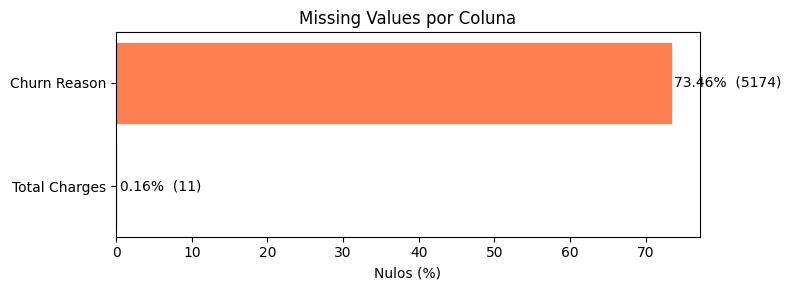

22:29:22 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\missing_values.png


In [29]:
# ── Análise de valores ausentes ───────────────────────────────────────────────
missing_values = pd.DataFrame(
    {
        "Coluna": df_eda.columns,
        "Qtd_Nulos": df_eda.isnull().sum(),
        "Pct_Nulos": (df_eda.isnull().sum() / len(df_eda) * 100).round(2),
    }
)

missing_values = missing_values[missing_values["Qtd_Nulos"] > 0].sort_values(
    by="Pct_Nulos", ascending=False
)
display(missing_values)

if len(missing_values) > 0:
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing_values) * 1.2)))

    ax.barh(
        missing_values["Coluna"],
        missing_values["Pct_Nulos"],
        color=CORES["destaque"],
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_xlabel("Nulos (%)")
    ax.set_title("Missing Values por Coluna")
    ax.invert_yaxis()

    for i, (_, row) in enumerate(missing_values.iterrows()):
        ax.text(
            row["Pct_Nulos"] + 0.3,
            i,
            f"{row['Pct_Nulos']}%  ({int(row['Qtd_Nulos'])})",
            va="center",
            fontsize=10,
        )
        logger.info(
            "Nulos | %s | count=%d | %.2f%%",
            row["Coluna"],
            int(row["Qtd_Nulos"]),
            row["Pct_Nulos"],
        )

    plt.tight_layout()
    output_path = REPORTS_FIGURES / "missing_values.png"
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()
    logger.info("Artefato salvo: %s", output_path)
else:
    logger.info("Nenhum missing value detectado no dataset.")

### 3.2 Linhas duplicadas

Verificação de registros idênticos em todas as colunas. Duplicatas exactas indicariam
erros de coleta ou joins incorretos no pipeline de dados upstream.


In [30]:
n_dup = df_eda.duplicated().sum()
logger.info("Linhas duplicadas encontradas: %d", n_dup)  # Esperado: 0

22:29:22 | INFO | Linhas duplicadas encontradas: 0


### 3.3 Distribuição da variável target (`Churn Value`)

O desbalanceamento de classes é um fato operacional: a maioria dos clientes não cancela.
Um **ratio < 0,5** sinaliza que métricas como acurácia são enganosas (um modelo que
classifica tudo como "não cancelou" atingiria 73% de acurácia sem aprender nada).

As estratégias de mitigação a serem avaliadas na modelagem são:
- `class_weight='balanced'` nos modelos Scikit-Learn (Regressão Logística).
- `pos_weight` no `BCEWithLogitsLoss` do PyTorch (MLP).
- SMOTE como fallback se o Recall permanecer insatisfatório.


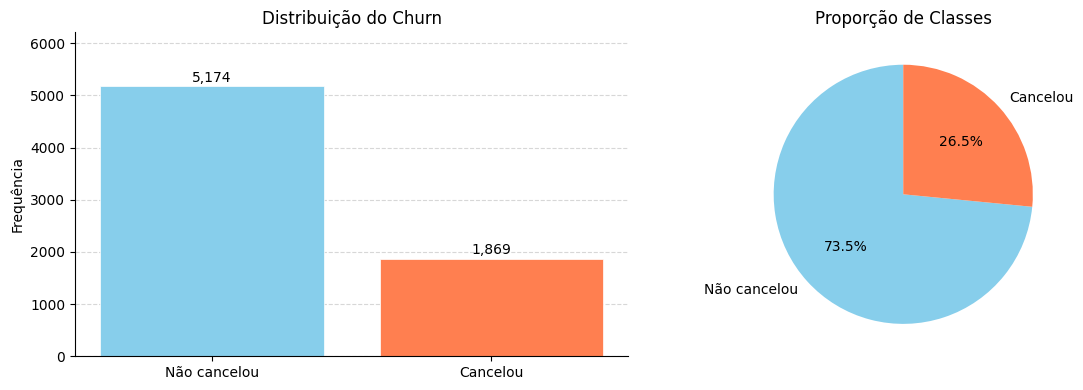

22:29:22 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\churn_distribution.png
22:29:22 | INFO | Target | Não cancelou (=0) | count=5174 | 73.46%
22:29:22 | INFO | Target | Cancelou (=1) | count=1869 | 26.54%
22:29:22 | WARNING | Dataset desbalanceado (ratio=0.36) — usar class_weight='balanced' ou SMOTE na modelagem.


In [31]:
target_counts = df_eda[TARGET].value_counts()
target_pct = df_eda[TARGET].value_counts(normalize=True).mul(100).round(2)

labels = {0: "Não cancelou", 1: "Cancelou"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Barras — frequência absoluta ──────────────────────────────────────────────
bar_labels = [labels[i] for i in target_counts.index]
bars = axes[0].bar(
    bar_labels,
    target_counts.values,
    color=[CORES["primaria"], CORES["destaque"]],
    edgecolor="white",
    linewidth=0.5,
    zorder=2,
)
for bar, count in zip(bars, target_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição do Churn")
axes[0].set_ylim(0, target_counts.max() * 1.2)
axes[0].yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
axes[0].set_axisbelow(True)
axes[0].spines[["top", "right"]].set_visible(False)

# ── Pizza — proporção ─────────────────────────────────────────────────────────
axes[1].pie(
    target_counts.values,
    labels=[labels[i] for i in target_counts.index],
    autopct="%1.1f%%",
    colors=[CORES["primaria"], CORES["destaque"]],
    startangle=90,
)
axes[1].set_title("Proporção de Classes")

plt.tight_layout()
output_path = REPORTS_FIGURES / "churn_distribution.png"
plt.savefig(output_path, dpi=120, bbox_inches="tight")
plt.show()
plt.close()
logger.info("Artefato salvo: %s", output_path)

for idx in target_counts.index:
    logger.info(
        "Target | %s (=%d) | count=%d | %.2f%%",
        labels[idx],
        idx,
        target_counts[idx],
        target_pct[idx],
    )

ratio = target_counts.min() / target_counts.max()
if ratio < 0.5:
    logger.warning(
        "Dataset desbalanceado (ratio=%.2f) — usar class_weight='balanced' ou SMOTE na modelagem.",
        ratio,
    )
else:
    logger.info("Dataset balanceado (ratio=%.2f).", ratio)

### 3.4 Exportação do dataset tipado (`telco_typed.parquet`)

Antes de avançar para a EDA, descartamos as colunas de identificação, geolocalização e
as variáveis de pós-avaliação (`COLS_POS`). O resultado — **shape `(7043, 20)`** — é salvo
como `telco_typed.parquet` e serve de ponto de entrada comum para todos os notebooks
subsequentes desta fase.

> **Nota:** `Total Charges` permanece no dataset neste momento (com seus 11 nulos intactos).
> A imputação por `0.0` será aplicada no pipeline de pré-processamento, mantendo a
> rastreabilidade da decisão de negócio documentada acima.


In [32]:
cols_drop = COLS_ID + COLS_POS + [LABEL_COL]

df_interim = df_eda.drop(columns=cols_drop).copy()

df_interim.to_parquet(DATA_INTERIM / "telco_typed.parquet", index=False)
logger.info(
    "Dataset salvo: " + str(DATA_INTERIM / "telco_typed.parquet") + " — shape: %s",
    df_interim.shape,
)
logger.info("Colunas deletadas: %s", cols_drop)

22:29:23 | INFO | Dataset salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\data\interim\telco_typed.parquet — shape: (7043, 20)
22:29:23 | INFO | Colunas deletadas: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Score', 'CLTV', 'Churn Reason', 'Churn Label']


In [33]:
# Ponto de entrada das análises abaixo — leitura do parquet tipado
df = pd.read_parquet(DATA_INTERIM / "telco_typed.parquet")
logger.info("Dataset carregado. Shape: %s", df.shape)
df.head(5)

22:29:23 | INFO | Dataset carregado. Shape: (7043, 20)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


---
## 4. Análise Univariada — Variáveis Numéricas

Para cada uma das 3 variáveis numéricas (`Tenure Months`, `Monthly Charges`,
`Total Charges`) são calculados:

- **Estatísticas descritivas:** média, mediana, desvio padrão, min, max, Q1, Q3, IQR.
- **Detecção de outliers (2 critérios):**
  - *IQR:* pontos fora de `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]`.
  - *Z-Score:* pontos com `|z| > 3`.
- **Visualização:** histograma de contagem + boxplot anotado.

> ⚠️ **Importante — escopo desta análise:** os outliers são calculados sobre o
> **dataset completo**, sem segmentação por classe de churn. O resultado `outliers_iqr=0`
> reflete que, na distribuição agregada de todos os clientes, nenhum ponto extrapola os
> limites globais de IQR.
>
> Na **Seção 6** (análise bivariada), os cálculos são refeitos **dentro de cada grupo
> (Churn=0 e Churn=1)**. Ali o grupo `Churn=1` tem distribuição mais comprimida
> (clientes com pouco tempo de casa) — e alguns clientes de alto valor que cancelaram
> cedo aparecem como outliers *dentro do próprio grupo*, resultando em 5,83% de
> outliers IQR para `Total Charges` no grupo churned.
> **Não há contradição:** são dois escopos de análise distintos e complementares.


22:29:23 | INFO | Análise univariada iniciada para 3 variáveis numéricas.


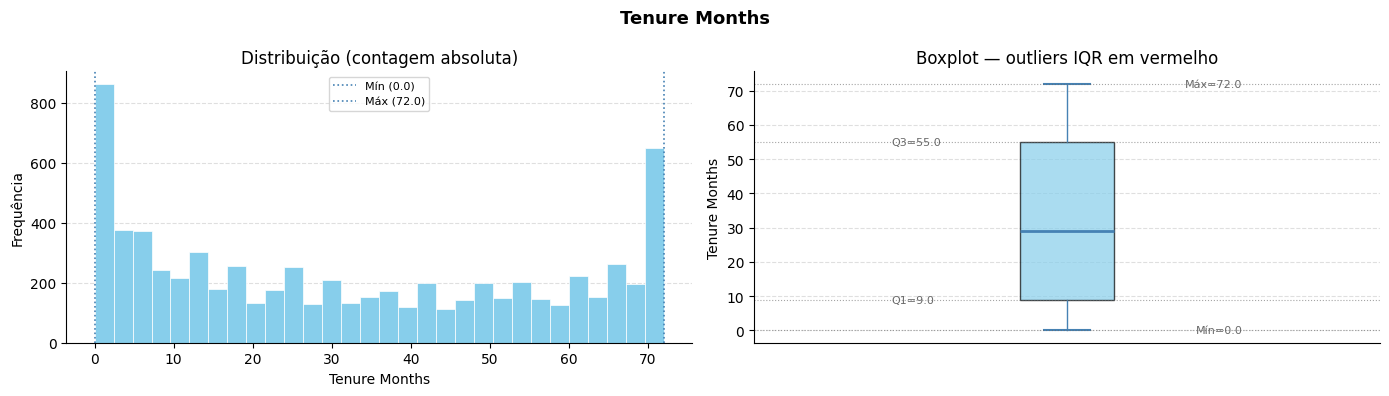

22:29:23 | INFO | Tenure Months | n=7043 | média=32.37 | mediana=29.00 | std=24.56 | min=0.00 | max=72.00 | q1=9.00 | q3=55.00 | iqr=46.00 | lim_inf=-60.00 | lim_sup=124.00 | outliers_iqr=0 (0.00%) | outliers_zscore=0 (0.00%)
22:29:23 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_num_tenure_months.png


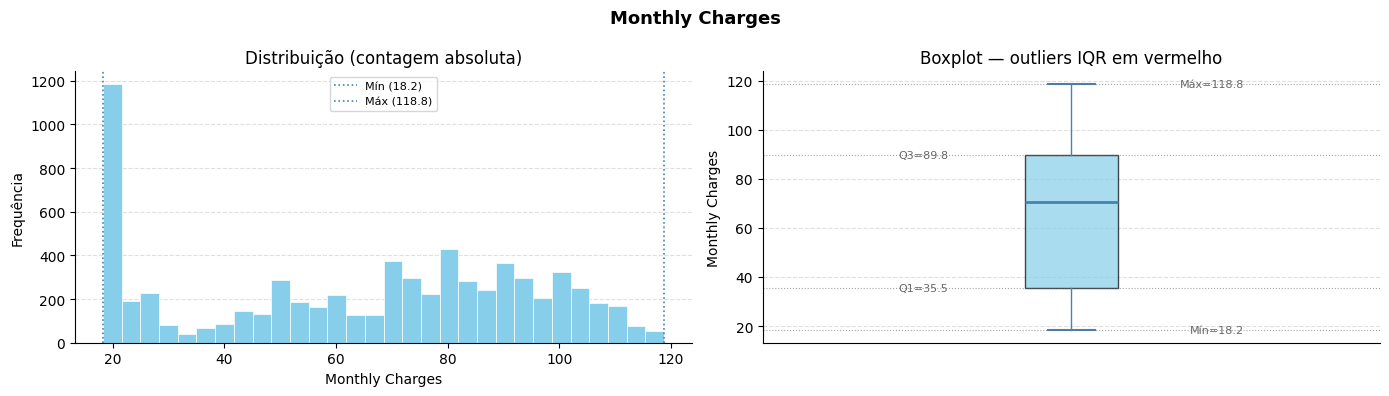

22:29:23 | INFO | Monthly Charges | n=7043 | média=64.76 | mediana=70.35 | std=30.09 | min=18.25 | max=118.75 | q1=35.50 | q3=89.85 | iqr=54.35 | lim_inf=-46.02 | lim_sup=171.38 | outliers_iqr=0 (0.00%) | outliers_zscore=0 (0.00%)
22:29:23 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_num_monthly_charges.png


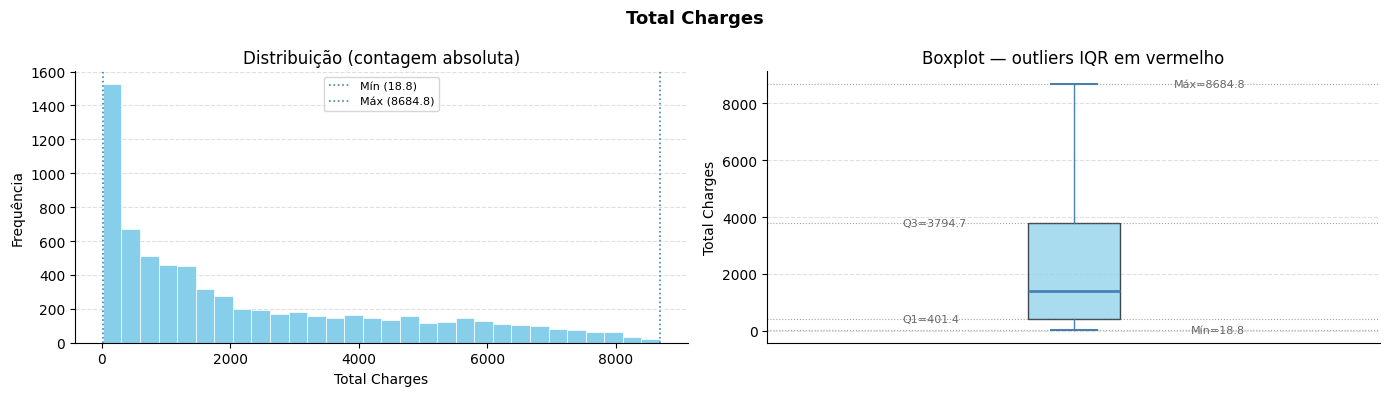

22:29:23 | INFO | Total Charges | n=7032 | média=2283.30 | mediana=1397.47 | std=2266.77 | min=18.80 | max=8684.80 | q1=401.45 | q3=3794.74 | iqr=3393.29 | lim_inf=-4688.48 | lim_sup=8884.67 | outliers_iqr=0 (0.00%) | outliers_zscore=0 (0.00%)
22:29:23 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_num_total_charges.png
22:29:23 | INFO | Análise univariada finalizada para 3 variáveis numéricas.


In [34]:
logger.info("Análise univariada iniciada para %d variáveis numéricas.", len(COLS_NUM))

for col in COLS_NUM:
    series = df[col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    val_min = series.min()
    val_max = series.max()

    # Outliers — escopo: distribuição GLOBAL (todos os clientes)
    mask_iqr = (series < lim_inf) | (series > lim_sup)
    n_out_iqr = mask_iqr.sum()
    pct_out_iqr = n_out_iqr / len(series) * 100

    z_scores = np.abs(stats.zscore(series))
    mask_z = z_scores > 3
    n_out_z = mask_z.sum()
    pct_out_z = n_out_z / len(series) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(col, fontsize=13, fontweight="bold")

    axes[0].hist(
        series,
        bins=30,
        color=CORES["primaria"],
        edgecolor="white",
        linewidth=0.5,
        zorder=2,
    )
    axes[0].axvline(
        val_min,
        color=CORES["secundaria"],
        linestyle=":",
        linewidth=1.2,
        label=f"Mín ({val_min:.1f})",
    )
    axes[0].axvline(
        val_max,
        color=CORES["secundaria"],
        linestyle=":",
        linewidth=1.2,
        label=f"Máx ({val_max:.1f})",
    )
    axes[0].set_title("Distribuição (contagem absoluta)")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequência")
    axes[0].yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    axes[0].set_axisbelow(True)
    axes[0].spines[["top", "right"]].set_visible(False)
    axes[0].legend(fontsize=8)

    axes[1].boxplot(
        series,
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor=CORES["primaria"], alpha=0.7),
        medianprops=dict(color=CORES["secundaria"], linewidth=2),
        whiskerprops=dict(color=CORES["secundaria"], linewidth=1),
        capprops=dict(color=CORES["secundaria"], linewidth=1.5),
        flierprops=dict(marker="o", color=CORES["alerta"], alpha=0.5, markersize=4),
    )
    for val, label, side in [
        (q1, f"Q1={q1:.1f}", "left"),
        (q3, f"Q3={q3:.1f}", "left"),
        (val_min, f"Mín={val_min:.1f}", "right"),
        (val_max, f"Máx={val_max:.1f}", "right"),
    ]:
        axes[1].axhline(
            val, color=CORES["neutro"], linestyle=":", linewidth=0.8, alpha=0.6
        )
        x_pos = 0.72 if side == "left" else 1.28
        axes[1].text(
            x_pos,
            val,
            label,
            va="center",
            fontsize=8,
            color=CORES["neutro"],
            ha="left" if side == "left" else "right",
        )
    axes[1].set_title("Boxplot — outliers IQR em vermelho")
    axes[1].set_ylabel(col)
    axes[1].set_xticks([])
    axes[1].yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    axes[1].set_axisbelow(True)
    axes[1].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    output_path = (
        REPORTS_FIGURES_UNIVARIADA
        / f"univariate_num_{col.lower().replace(' ', '_')}.png"
    )
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

    logger.info(
        "%s | n=%d | média=%.2f | mediana=%.2f | std=%.2f | "
        "min=%.2f | max=%.2f | q1=%.2f | q3=%.2f | iqr=%.2f | "
        "lim_inf=%.2f | lim_sup=%.2f | "
        "outliers_iqr=%d (%.2f%%) | outliers_zscore=%d (%.2f%%)",
        col,
        len(series),
        series.mean(),
        series.median(),
        series.std(),
        val_min,
        val_max,
        q1,
        q3,
        iqr,
        lim_inf,
        lim_sup,
        n_out_iqr,
        pct_out_iqr,
        n_out_z,
        pct_out_z,
    )
    logger.info("Artefato salvo: %s", output_path)

logger.info("Análise univariada finalizada para %d variáveis numéricas.", len(COLS_NUM))

### 4.1 Assimetria, Curtose e Normalidade (Shapiro-Wilk)

O histograma da seção anterior revela a forma visual da distribuição. Aqui
quantificamos o desvio da normalidade com três métricas:

| Métrica | O que mede | Referência normal |
|---------|-----------|-------------------|
| **Skewness** | Assimetria (< 0 = cauda esquerda, > 0 = cauda direita) | ≈ 0 |
| **Excess Kurtosis** | Peso das caudas vs. distribuição normal | ≈ 0 |
| **Shapiro-Wilk p** | Teste formal de normalidade (p > 0.05 = não rejeita normal) | > 0.05 |

> **Por que isso importa para a MLP?** Redes Neurais são sensíveis à escala dos
> inputs. Uma variável com forte assimetria à direita como `Total Charges`
> (skewness ≈ 0.96) comprime a maioria dos valores em uma faixa estreita enquanto
> estica a cauda — causando gradientes instáveis. A transformação `log1p` ou
> `PowerTransformer` será aplicada no pipeline de pré-processamento.


22:29:23 | INFO | Análise da assimetria e curtose iniciada para 3 variáveis numéricas.


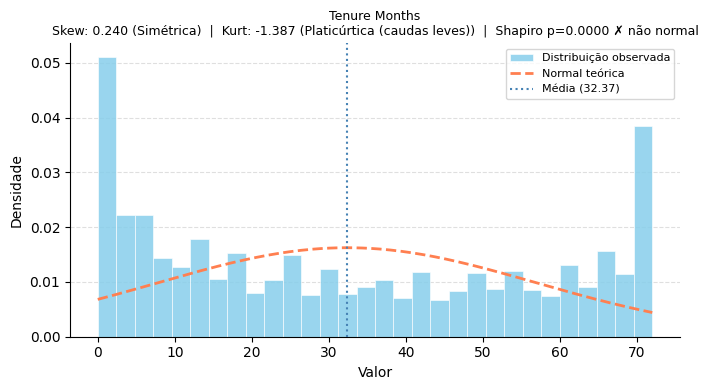

22:29:24 | INFO | Tenure Months | skewness=0.240 (Simétrica) | kurtosis=-1.387 (Platicúrtica (caudas leves)) | shapiro_p=0.0000 | normal=False
22:29:24 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_skew_kurt_tenure_months.png
22:29:24 | WARNING | Tenure Months | distribuição não normal (Shapiro p=0.0000) — considerar log1p ou Box-Cox na Etapa 1.03


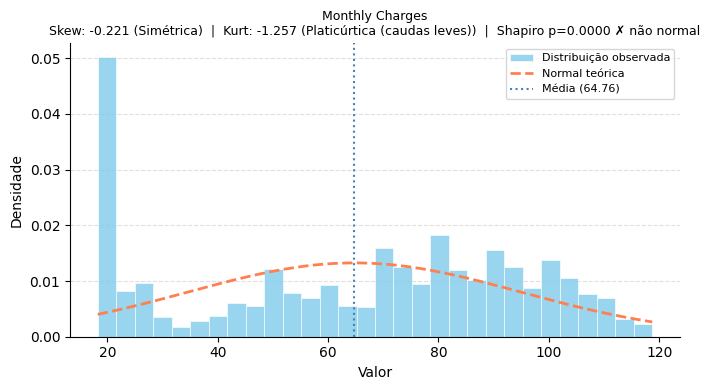

22:29:24 | INFO | Monthly Charges | skewness=-0.221 (Simétrica) | kurtosis=-1.257 (Platicúrtica (caudas leves)) | shapiro_p=0.0000 | normal=False
22:29:24 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_skew_kurt_monthly_charges.png
22:29:24 | WARNING | Monthly Charges | distribuição não normal (Shapiro p=0.0000) — considerar log1p ou Box-Cox na Etapa 1.03


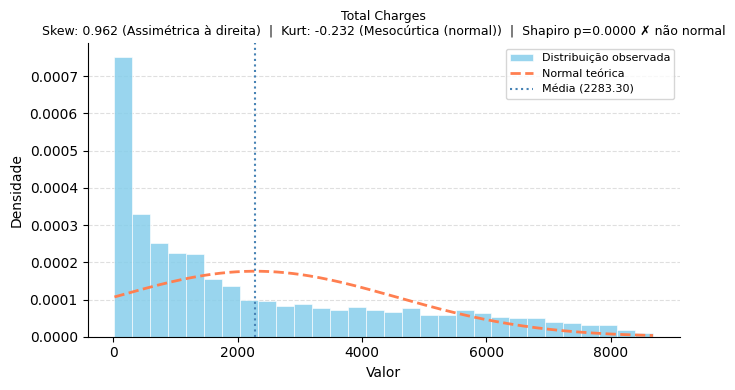

22:29:24 | INFO | Total Charges | skewness=0.962 (Assimétrica à direita) | kurtosis=-0.232 (Mesocúrtica (normal)) | shapiro_p=0.0000 | normal=False
22:29:24 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_skew_kurt_total_charges.png
22:29:24 | WARNING | Total Charges | distribuição não normal (Shapiro p=0.0000) — considerar log1p ou Box-Cox na Etapa 1.03
22:29:24 | INFO | Análise da assimetria e curtose finalizada para 3 variáveis numéricas.


,Coluna,Skewness,Kurtosis,Skew_interp,Kurt_interp,Shapiro_p,Normal
0,Tenure Months,0.240,-1.387,Simétrica,Platicúrtica (caudas leves),0.0,False
1,Monthly Charges,-0.221,-1.257,Simétrica,Platicúrtica (caudas leves),0.0,False
2,Total Charges,0.962,-0.232,Assimétrica à direita,Mesocúrtica (normal),0.0,False


In [35]:
logger.info(
    "Análise da assimetria e curtose iniciada para %d variáveis numéricas.",
    len(COLS_NUM),
)
distribution_stats = []

for col in COLS_NUM:
    series = df[col].dropna()
    skewness = series.skew()
    kurtosis = series.kurtosis()  # excess kurtosis (normal = 0)

    if abs(skewness) < 0.5:
        interp_skew = "Simétrica"
    elif skewness > 0:
        interp_skew = "Assimétrica à direita"
    else:
        interp_skew = "Assimétrica à esquerda"

    if abs(kurtosis) < 0.5:
        interp_kurt = "Mesocúrtica (normal)"
    elif kurtosis > 0:
        interp_kurt = "Leptocúrtica (caudas pesadas)"
    else:
        interp_kurt = "Platicúrtica (caudas leves)"

    # Shapiro-Wilk: limitado a 5000 amostras (exigência do scipy)
    amostra = series.sample(min(len(series), 5000), random_state=RANDOM_STATE)
    _, p_valor = stats.shapiro(amostra)
    normal = p_valor > 0.05

    distribution_stats.append(
        {
            "Coluna": col,
            "Skewness": round(skewness, 3),
            "Kurtosis": round(kurtosis, 3),
            "Skew_interp": interp_skew,
            "Kurt_interp": interp_kurt,
            "Shapiro_p": round(p_valor, 4),
            "Normal": normal,
        }
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(
        series,
        bins=30,
        color=CORES["primaria"],
        edgecolor="white",
        linewidth=0.5,
        density=True,
        alpha=0.85,
        zorder=2,
        label="Distribuição observada",
    )

    x = np.linspace(series.min(), series.max(), 200)
    curva_normal = stats.norm.pdf(x, series.mean(), series.std())
    ax.plot(
        x,
        curva_normal,
        color=CORES["destaque"],
        linewidth=2,
        linestyle="--",
        label="Normal teórica",
        zorder=3,
    )
    ax.axvline(
        series.mean(),
        color=CORES["secundaria"],
        linewidth=1.5,
        linestyle=":",
        label=f"Média ({series.mean():.2f})",
        zorder=3,
    )

    ax.set_title(
        f"{col}\n"
        f"Skew: {skewness:.3f} ({interp_skew})  |  "
        f"Kurt: {kurtosis:.3f} ({interp_kurt})  |  "
        f"Shapiro p={p_valor:.4f} {'✓ normal' if normal else '✗ não normal'}",
        fontsize=9,
    )
    ax.set_xlabel("Valor")
    ax.set_ylabel("Densidade")
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8)

    plt.tight_layout()
    output_path = (
        REPORTS_FIGURES_UNIVARIADA
        / f"univariate_skew_kurt_{col.lower().replace(' ', '_')}.png"
    )
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

    logger.info(
        "%s | skewness=%.3f (%s) | kurtosis=%.3f (%s) | shapiro_p=%.4f | normal=%s",
        col,
        skewness,
        interp_skew,
        kurtosis,
        interp_kurt,
        p_valor,
        normal,
    )
    logger.info("Artefato salvo: %s", output_path)

    if not normal:
        logger.warning(
            "%s | distribuição não normal (Shapiro p=%.4f) — considerar log1p ou Box-Cox na Etapa 1.03",
            col,
            p_valor,
        )

logger.info(
    "Análise da assimetria e curtose finalizada para %d variáveis numéricas.",
    len(COLS_NUM),
)

# Tabela resumo
pd.DataFrame(distribution_stats)

---
## 5. Análise Univariada — Variáveis Categóricas

Para cada uma das 16 variáveis categóricas são calculados:

- **Frequência absoluta e relativa** por categoria.
- **Categorias raras** (< 1% da base) — potenciais erros de digitação ou grupos
  insuficientes para generalização.
- **Alta concentração** (> 80% em uma categoria) — sinaliza baixo poder preditivo,
  pois o modelo tem pouca variação para aprender.
- **Distribuição uniforme teórica** (100 / n_categorias) — referência de equilíbrio.

> **Atenção às flags de alta concentração:**
> - `Phone Service`: 90,3% dos clientes têm o serviço → pouca discriminação.
> - `Senior Citizen`: 83,8% não são idosos.
>
> A decisão de descartar essas variáveis **só será tomada após a análise bivariada**,
> onde verificamos se a concentração reflete ou não ausência de sinal preditivo.


22:29:24 | INFO | Análise univariada iniciada para 16 variáveis categóricas.


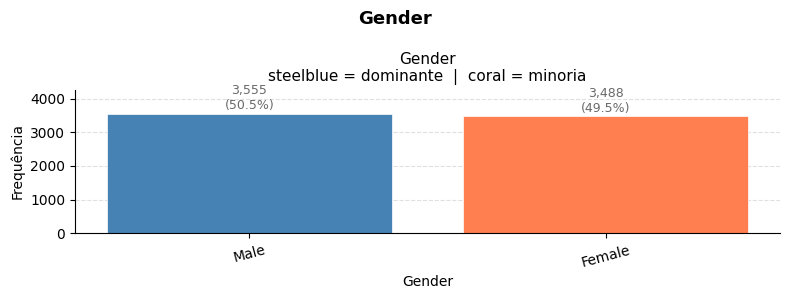

22:29:24 | INFO | Gender | n=7043 | nulos=0 | categorias=2 | dominante='Male' (50.5%) | minoria='Female' (49.5%) | dist_uniforme=50.0% | cats_raras=0 (<1%) | alta_concentracao=False
22:29:24 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_gender.png


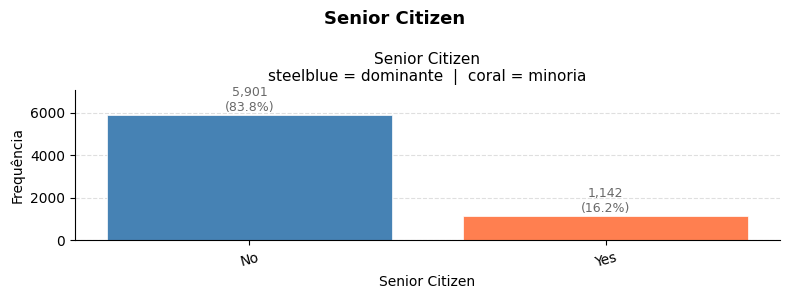

22:29:24 | INFO | Senior Citizen | n=7043 | nulos=0 | categorias=2 | dominante='No' (83.8%) | minoria='Yes' (16.2%) | dist_uniforme=50.0% | cats_raras=0 (<1%) | alta_concentracao=True
22:29:24 | WARNING | Senior Citizen | alta concentração: 'No' ocupa 83.8% — avaliar poder preditivo
22:29:24 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_senior_citizen.png


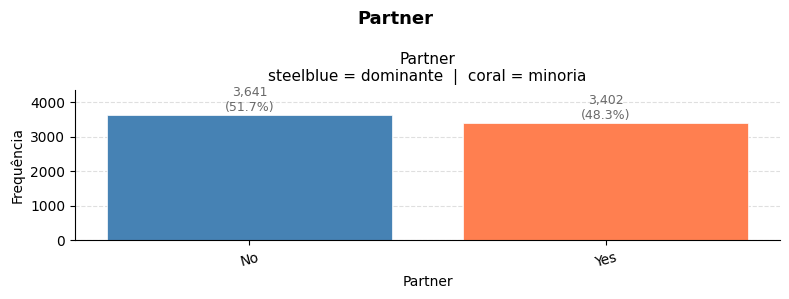

22:29:24 | INFO | Partner | n=7043 | nulos=0 | categorias=2 | dominante='No' (51.7%) | minoria='Yes' (48.3%) | dist_uniforme=50.0% | cats_raras=0 (<1%) | alta_concentracao=False
22:29:24 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_partner.png


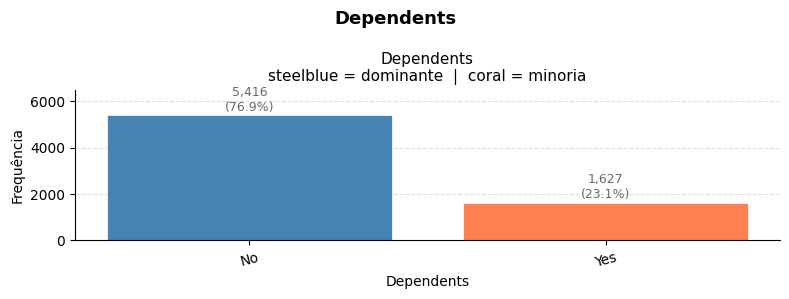

22:29:25 | INFO | Dependents | n=7043 | nulos=0 | categorias=2 | dominante='No' (76.9%) | minoria='Yes' (23.1%) | dist_uniforme=50.0% | cats_raras=0 (<1%) | alta_concentracao=False
22:29:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_dependents.png


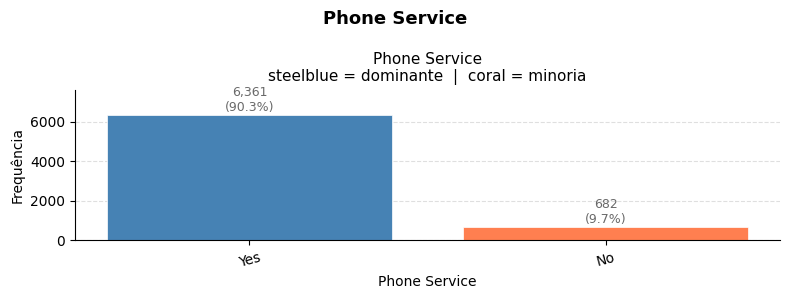

22:29:25 | INFO | Phone Service | n=7043 | nulos=0 | categorias=2 | dominante='Yes' (90.3%) | minoria='No' (9.7%) | dist_uniforme=50.0% | cats_raras=0 (<1%) | alta_concentracao=True
22:29:25 | WARNING | Phone Service | alta concentração: 'Yes' ocupa 90.3% — avaliar poder preditivo
22:29:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_phone_service.png


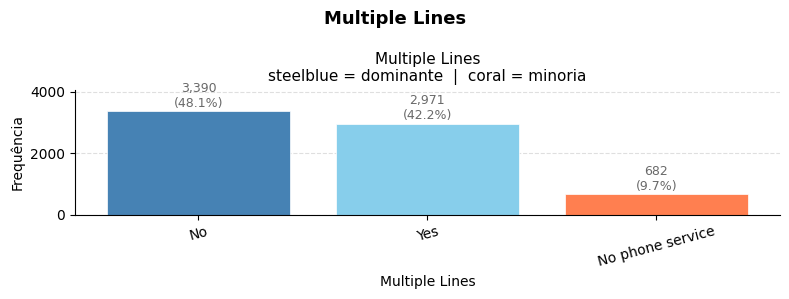

22:29:25 | INFO | Multiple Lines | n=7043 | nulos=0 | categorias=3 | dominante='No' (48.1%) | minoria='No phone service' (9.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:29:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_multiple_lines.png


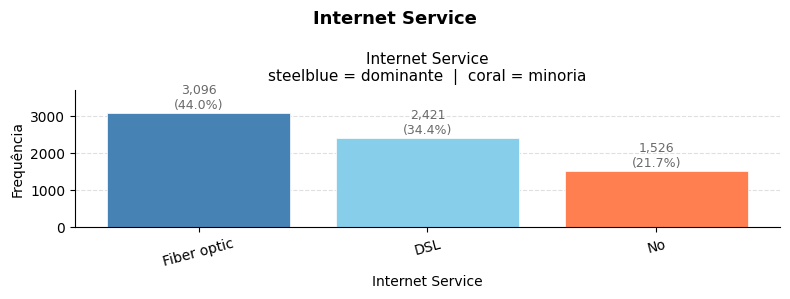

22:29:25 | INFO | Internet Service | n=7043 | nulos=0 | categorias=3 | dominante='Fiber optic' (44.0%) | minoria='No' (21.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:29:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_internet_service.png


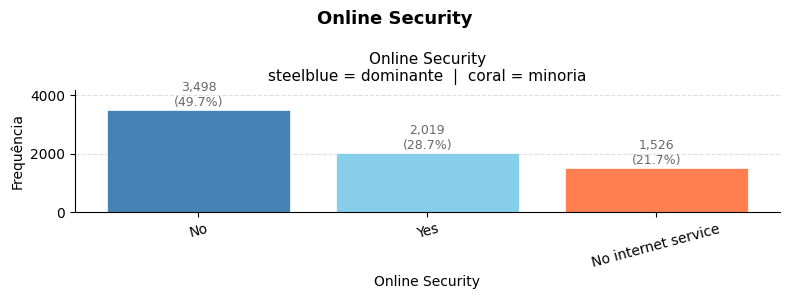

22:29:25 | INFO | Online Security | n=7043 | nulos=0 | categorias=3 | dominante='No' (49.7%) | minoria='No internet service' (21.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:29:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_online_security.png


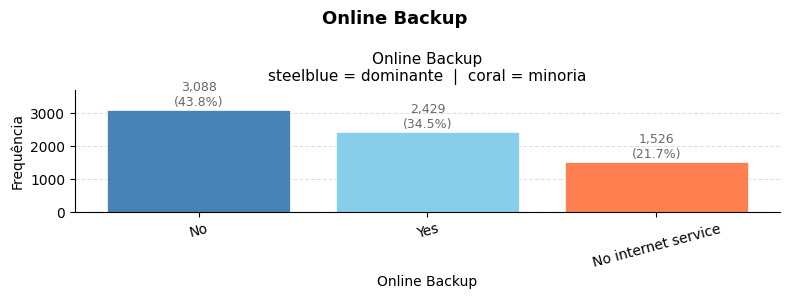

22:29:25 | INFO | Online Backup | n=7043 | nulos=0 | categorias=3 | dominante='No' (43.8%) | minoria='No internet service' (21.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:29:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_online_backup.png


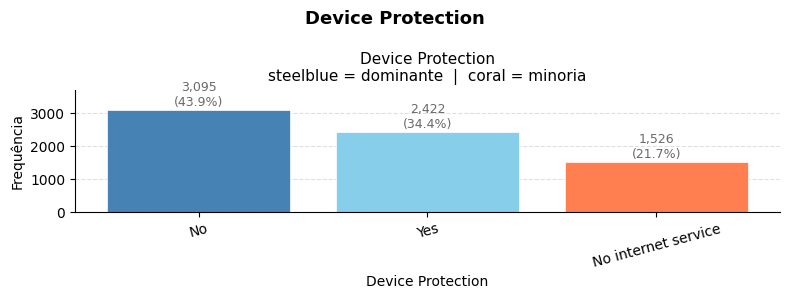

22:29:25 | INFO | Device Protection | n=7043 | nulos=0 | categorias=3 | dominante='No' (43.9%) | minoria='No internet service' (21.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:29:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_device_protection.png


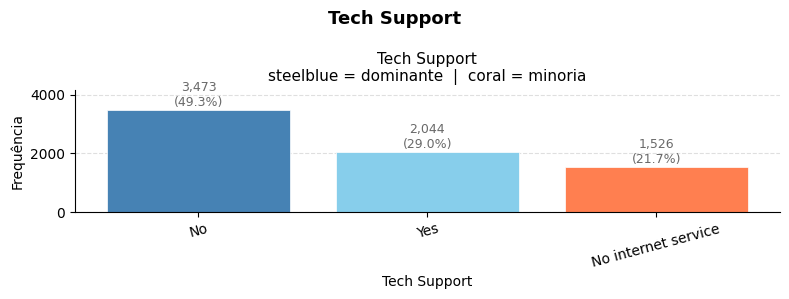

22:29:25 | INFO | Tech Support | n=7043 | nulos=0 | categorias=3 | dominante='No' (49.3%) | minoria='No internet service' (21.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:29:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_tech_support.png


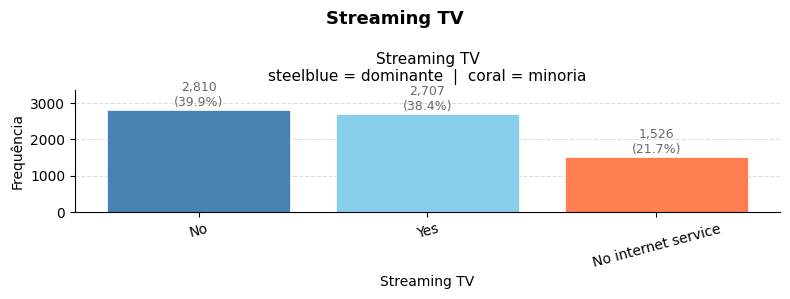

22:29:25 | INFO | Streaming TV | n=7043 | nulos=0 | categorias=3 | dominante='No' (39.9%) | minoria='No internet service' (21.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:29:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_streaming_tv.png


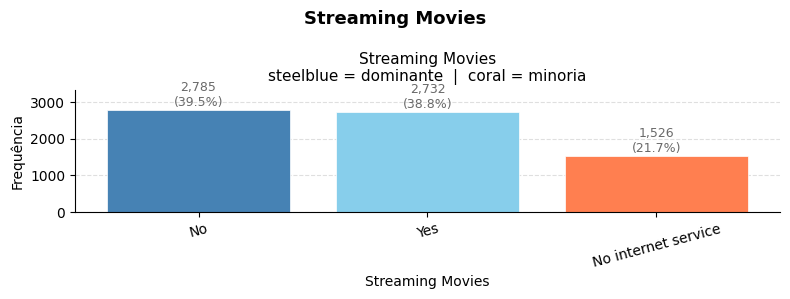

22:29:26 | INFO | Streaming Movies | n=7043 | nulos=0 | categorias=3 | dominante='No' (39.5%) | minoria='No internet service' (21.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:29:26 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_streaming_movies.png


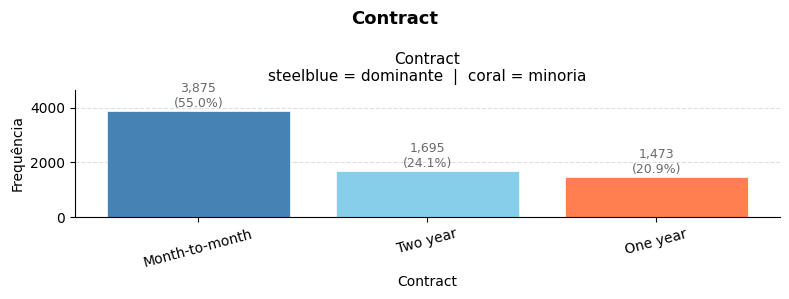

22:29:26 | INFO | Contract | n=7043 | nulos=0 | categorias=3 | dominante='Month-to-month' (55.0%) | minoria='One year' (20.9%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:29:26 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_contract.png


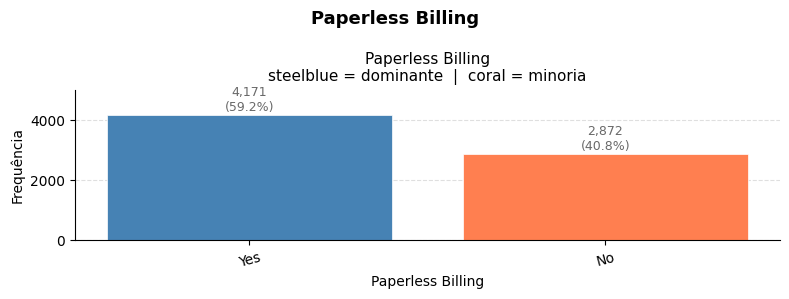

22:29:26 | INFO | Paperless Billing | n=7043 | nulos=0 | categorias=2 | dominante='Yes' (59.2%) | minoria='No' (40.8%) | dist_uniforme=50.0% | cats_raras=0 (<1%) | alta_concentracao=False
22:29:26 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_paperless_billing.png


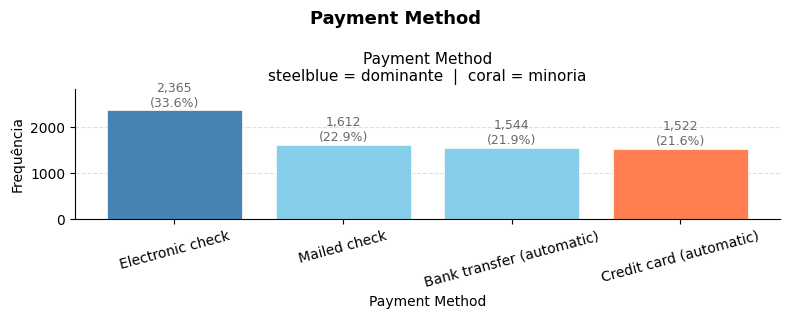

22:29:26 | INFO | Payment Method | n=7043 | nulos=0 | categorias=4 | dominante='Electronic check' (33.6%) | minoria='Credit card (automatic)' (21.6%) | dist_uniforme=25.0% | cats_raras=0 (<1%) | alta_concentracao=False
22:29:26 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_payment_method.png
22:29:26 | INFO | Análise univariada finalizada para 16 variáveis categóricas.


In [36]:
logger.info("Análise univariada iniciada para %d variáveis categóricas.", len(COLS_CAT))

for col in COLS_CAT:
    series = df[col].dropna()
    freq_abs = series.value_counts()
    freq_rel = series.value_counts(normalize=True).mul(100).round(1)
    n_cats = series.nunique()
    n_nulos = df[col].isnull().sum()
    dominante = freq_abs.index[0]
    minoria = freq_abs.index[-1]

    cats_raras = freq_rel[freq_rel < 1.0]
    alta_concentracao = freq_rel.iloc[0] > 80.0
    dist_uniforme = round(100 / n_cats, 1)

    altura = max(3, n_cats * 0.8)
    fig, ax = plt.subplots(figsize=(8, altura))
    fig.suptitle(col, fontsize=13, fontweight="bold")

    cores_barras = [
        CORES["secundaria"]
        if cat == dominante
        else CORES["destaque"]
        if cat == minoria
        else CORES["primaria"]
        for cat in freq_abs.index
    ]
    bars = ax.bar(
        freq_abs.index,
        freq_abs.values,
        color=cores_barras,
        edgecolor="white",
        linewidth=0.5,
        zorder=2,
    )

    for bar, count, pct in zip(bars, freq_abs.values, freq_rel.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + freq_abs.max() * 0.01,
            f"{count:,}\n({pct}%)",
            ha="center",
            va="bottom",
            fontsize=9,
            color=CORES["neutro"],
        )

    ax.set_title(f"{col}\nsteelblue = dominante  |  coral = minoria", fontsize=11)
    ax.set_ylabel("Frequência")
    ax.set_xlabel(col)
    ax.set_ylim(0, freq_abs.max() * 1.2)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=15)

    plt.tight_layout()
    output_path = (
        REPORTS_FIGURES_UNIVARIADA
        / f"univariate_cat_{col.lower().replace(' ', '_')}.png"
    )
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

    logger.info(
        "%s | n=%d | nulos=%d | categorias=%d | "
        "dominante='%s' (%.1f%%) | minoria='%s' (%.1f%%) | "
        "dist_uniforme=%.1f%% | cats_raras=%d (<1%%) | alta_concentracao=%s",
        col,
        len(series),
        n_nulos,
        n_cats,
        dominante,
        freq_rel.loc[dominante],
        minoria,
        freq_rel.loc[minoria],
        dist_uniforme,
        len(cats_raras),
        alta_concentracao,
    )

    for cat, pct in cats_raras.items():
        logger.warning(
            "%s | categoria rara: '%s' = %.1f%% (%d registros)",
            col,
            cat,
            pct,
            freq_abs.loc[cat],
        )
    if alta_concentracao:
        logger.warning(
            "%s | alta concentração: '%s' ocupa %.1f%% — avaliar poder preditivo",
            col,
            dominante,
            freq_rel.iloc[0],
        )
    logger.info("Artefato salvo: %s", output_path)

logger.info(
    "Análise univariada finalizada para %d variáveis categóricas.", len(COLS_CAT)
)

---
## 6. Análise Bivariada — Numéricas vs. Target

Aqui cada variável numérica é segmentada em dois grupos: `Churn=0` e `Churn=1`.
São calculados:

- **Estatísticas por grupo** (média, mediana, desvio padrão).
- **Correlação de Pearson** com o target.
- **Cohen's d** — tamanho do efeito (magnitude da separação entre os grupos):
  - |d| < 0.2 → Negligenciável | 0.2–0.5 → Pequeno | 0.5–0.8 → Médio | > 0.8 → **Grande**
- **Outliers recalculados dentro de cada grupo** (IQR e Z-Score).

> ⚠️ **Reconciliando com a Seção 4 (Univariada) — por que surgem outliers aqui?**
>
> A análise univariada (`outliers_iqr = 0` para todas as variáveis) foi calculada
> sobre o **dataset inteiro**. A análise bivariada recalcula os limites **dentro de
> cada subgrupo**, o que produz resultados diferentes. Dois casos ilustram esse
> fenômeno com mecanismos distintos:
>
> ---
>
> **`Tenure Months` — 23 outliers IQR (1,23%) no grupo Churn=1, mas 0 por Z-Score**
>
> O grupo `Churn=1` tem distribuição fortemente assimétrica à direita:
> `mediana=10 meses`, `std=19,53` — a maioria dos clientes que cancelou saiu nos
> primeiros meses. Isso comprime o IQR do subgrupo, estreitando o limite superior.
> Os 23 clientes que ficaram bastante tempo (e mesmo assim cancelaram) excedem esse
> limite estreito e aparecem como outliers IQR.
>
> No entanto, o **Z-Score reporta 0 outliers** para o mesmo grupo — e isso não é
> contradição. O Z-Score usa `média=17,98` e `std=19,53`, que têm amplitude
> suficiente para acomodar esses casos extremos sem que ultrapassem `|z| > 3`.
> Quando dois critérios divergem, o IQR é mais sensível em distribuições assimétricas
> (como esta), enquanto o Z-Score é mais conservador porque a cauda direita infla o
> desvio padrão, elevando o limiar de detecção.
>
> **Interpretação de negócio:** esses 23 clientes são "churners tardios" — ficaram
> meses ou anos e mesmo assim saíram. Representam um perfil de risco diferente
> (insatisfação acumulada, não impulsiva) e são **informativos para o modelo**, não
> ruído a ser removido.
>
> ---
>
> **`Total Charges` — 109 outliers IQR (5,83%) e 27 por Z-Score no grupo Churn=1**
>
> O grupo `Churn=1` tem distribuição comprimida (`mediana=703,55` vs. `1.683,60`
> no grupo No Churn) porque clientes que saem cedo acumulam menos cobrança total.
> Isso estreita o IQR do subgrupo → limite superior mais baixo → clientes de alto
> valor que cancelaram prematuramente aparecem como outliers *dentro do grupo*.
>
> Aqui o Z-Score **também detecta 27 outliers** (1,44%), confirmando que parte
> desses pontos é genuinamente extrema mesmo considerando o desvio padrão do grupo.
>
> - **Global (Seção 4):** limites baseados nos 7.043 registros →
>   `lim_sup ≈ 8.884`. O máximo global (8.684) não ultrapassa esse teto.
> - **Por grupo (Seção 6):** limites calculados apenas nos 1.869 clientes churned →
>   IQR mais estreito → teto mais baixo → outliers emergem.
>
> **Implicação para o modelo:** `Total Charges` apresenta distribuição
> heterogênea entre classes e redundância estrutural com `Tenure Months`
> (correlação=0,83, VIF≈8). Esses dois fatos em conjunto justificam sua
> **remoção na Seção 9**, tornando esse problema irrelevante.


22:29:26 | INFO | Análise bivariada avançada iniciada para 3 variáveis numéricas.
C:\Users\victo\AppData\Local\Temp\ipykernel_37512\1798994956.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = series_copy.groupby("bin")[TARGET].mean()
C:\Users\victo\AppData\Local\Temp\ipykernel_37512\1798994956.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


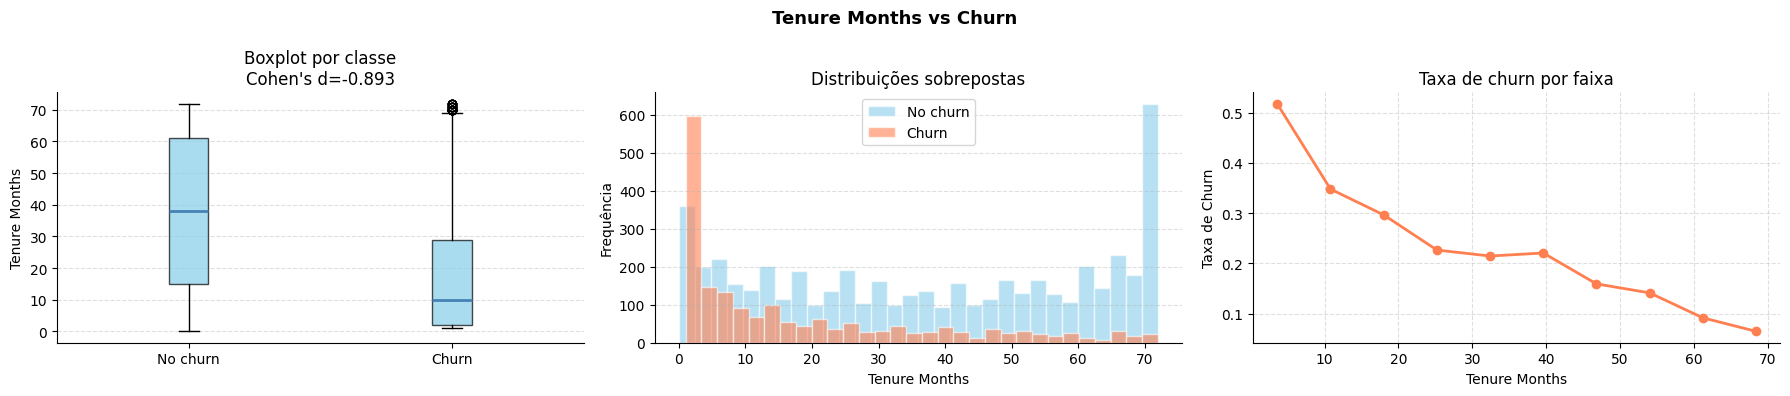

22:29:27 | INFO | Tenure Months | n0=5174 | n1=1869 | mean_0=37.57 | mean_1=17.98 | median_0=38.00 | median_1=10.00 | std_0=24.11 | std_1=19.53 | corr=-0.3522 | cohen_d=-0.8928 | p_value=0.000000 | grp0_outliers_iqr=0 (0.00%) | grp1_outliers_iqr=23 (1.23%) | grp0_outliers_z=0 (0.00%) | grp1_outliers_z=0 (0.00%)
22:29:27 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_num_tenure months.png
C:\Users\victo\AppData\Local\Temp\ipykernel_37512\1798994956.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = series_copy.groupby("bin")[TARGET].mean()
C:\Users\victo\AppData\Local\Temp\ipykernel_37512\1798994956.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot

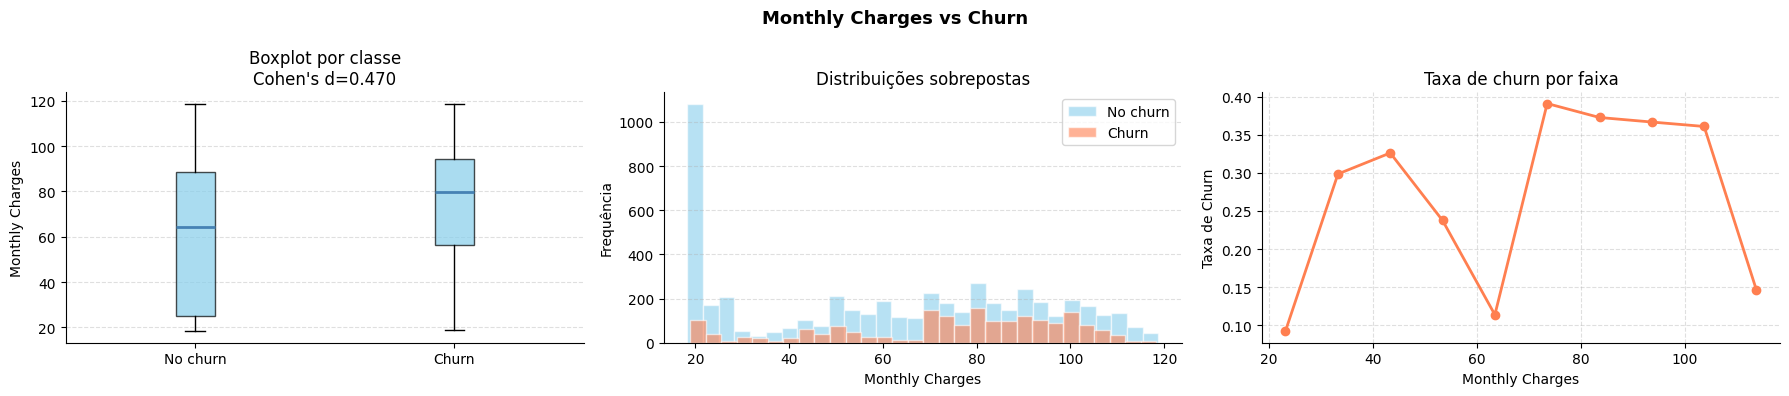

22:29:27 | INFO | Monthly Charges | n0=5174 | n1=1869 | mean_0=61.27 | mean_1=74.44 | median_0=64.43 | median_1=79.65 | std_0=31.09 | std_1=24.67 | corr=0.1934 | cohen_d=0.4695 | p_value=0.000000 | grp0_outliers_iqr=0 (0.00%) | grp1_outliers_iqr=0 (0.00%) | grp0_outliers_z=0 (0.00%) | grp1_outliers_z=0 (0.00%)
22:29:27 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_num_monthly charges.png
C:\Users\victo\AppData\Local\Temp\ipykernel_37512\1798994956.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = series_copy.groupby("bin")[TARGET].mean()
C:\Users\victo\AppData\Local\Temp\ipykernel_37512\1798994956.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplo

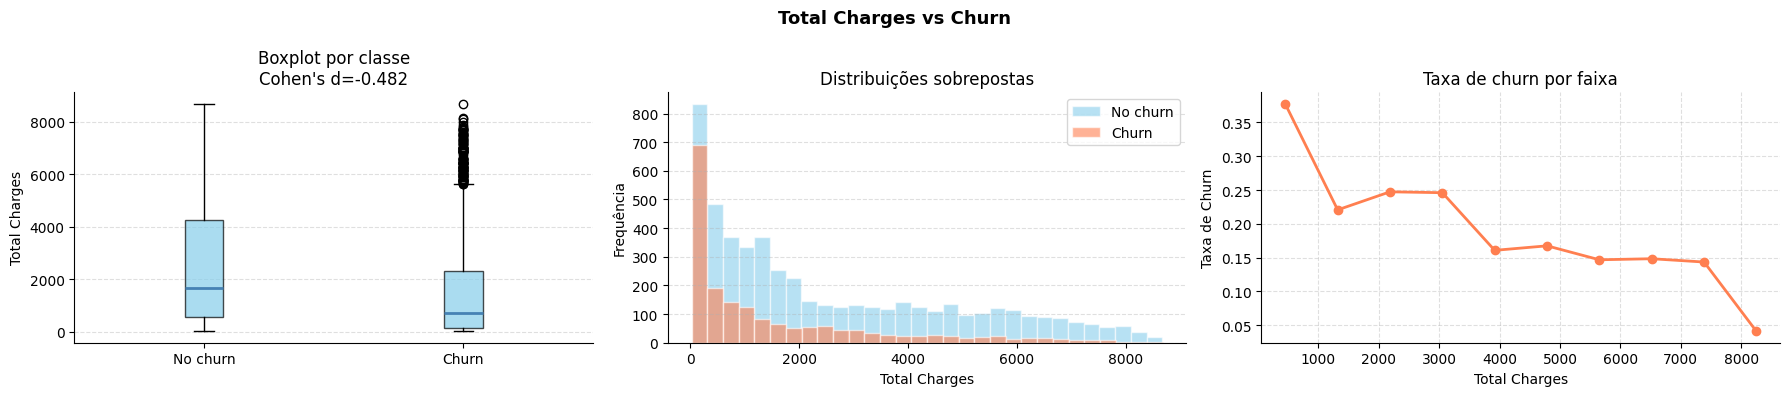

22:29:27 | INFO | Total Charges | n0=5163 | n1=1869 | mean_0=2555.34 | mean_1=1531.80 | median_0=1683.60 | median_1=703.55 | std_0=2329.46 | std_1=1890.82 | corr=-0.1995 | cohen_d=-0.4825 | p_value=0.000000 | grp0_outliers_iqr=0 (0.00%) | grp1_outliers_iqr=109 (5.83%) | grp0_outliers_z=0 (0.00%) | grp1_outliers_z=27 (1.44%)
22:29:27 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_num_total charges.png
22:29:27 | INFO | Análise bivariada avançada finalizada.


In [37]:
logger.info(
    "Análise bivariada avançada iniciada para %d variáveis numéricas.", len(COLS_NUM)
)

for col in COLS_NUM:
    series = df[[col, TARGET]].dropna()

    grp_0 = series[series[TARGET] == 0][col]
    grp_1 = series[series[TARGET] == 1][col]

    # ── Outliers calculados DENTRO de cada grupo (escopo: subgrupo) ───────────
    def compute_outliers(s):
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr
        mask_iqr = (s < lim_inf) | (s > lim_sup)
        n_iqr = mask_iqr.sum()
        pct_iqr = n_iqr / len(s) * 100
        z_scores = np.abs(stats.zscore(s))
        mask_z = z_scores > 3
        n_z = mask_z.sum()
        pct_z = n_z / len(s) * 100
        return {"n_iqr": n_iqr, "pct_iqr": pct_iqr, "n_z": n_z, "pct_z": pct_z}

    out_0 = compute_outliers(grp_0)
    out_1 = compute_outliers(grp_1)

    mean_0, mean_1 = grp_0.mean(), grp_1.mean()
    med_0, med_1 = grp_0.median(), grp_1.median()
    std_0, std_1 = grp_0.std(), grp_1.std()

    # Cohen's d
    pooled_std = np.sqrt((std_0**2 + std_1**2) / 2)
    cohen_d = (mean_1 - mean_0) / pooled_std if pooled_std > 0 else 0

    # Correlação e teste Mann-Whitney
    corr = series[col].corr(series[TARGET])
    _, p_value = stats.mannwhitneyu(grp_0, grp_1, alternative="two-sided")

    # ── Bins para taxa de churn ────────────────────────────────────────────────
    series_copy = series.copy()
    series_copy["bin"] = pd.cut(series_copy[col], bins=10)
    churn_rate = series_copy.groupby("bin")[TARGET].mean()
    bin_centers = [interval.mid for interval in churn_rate.index]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"{col} vs Churn", fontsize=13, fontweight="bold")

    # Boxplot lado a lado
    axes[0].boxplot(
        [grp_0.dropna(), grp_1.dropna()],
        labels=["No churn", "Churn"],
        patch_artist=True,
        boxprops=dict(facecolor=CORES["primaria"], alpha=0.7),
        medianprops=dict(color=CORES["secundaria"], linewidth=2),
    )
    axes[0].set_title(f"Boxplot por classe\nCohen's d={cohen_d:.3f}")
    axes[0].set_ylabel(col)
    axes[0].yaxis.grid(True, linestyle="--", alpha=0.4)
    axes[0].spines[["top", "right"]].set_visible(False)

    # Histogramas sobrepostos
    axes[1].hist(
        grp_0,
        bins=30,
        alpha=0.6,
        label="No churn",
        color=CORES["primaria"],
        edgecolor="white",
    )
    axes[1].hist(
        grp_1,
        bins=30,
        alpha=0.6,
        label="Churn",
        color=CORES["destaque"],
        edgecolor="white",
    )
    axes[1].set_title("Distribuições sobrepostas")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Frequência")
    axes[1].legend()
    axes[1].yaxis.grid(True, linestyle="--", alpha=0.4)
    axes[1].spines[["top", "right"]].set_visible(False)

    # Taxa de churn por faixa
    axes[2].plot(
        bin_centers, churn_rate.values, marker="o", color=CORES["destaque"], linewidth=2
    )
    axes[2].set_title("Taxa de churn por faixa")
    axes[2].set_xlabel(col)
    axes[2].set_ylabel("Taxa de Churn")
    axes[2].grid(True, linestyle="--", alpha=0.4)
    axes[2].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    output_path = REPORTS_FIGURES_MULTIVARIADA / f"bivariate_num_{col.lower()}.png"
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

    logger.info(
        "%s | n0=%d | n1=%d | mean_0=%.2f | mean_1=%.2f | "
        "median_0=%.2f | median_1=%.2f | std_0=%.2f | std_1=%.2f | "
        "corr=%.4f | cohen_d=%.4f | p_value=%.6f | "
        "grp0_outliers_iqr=%d (%.2f%%) | grp1_outliers_iqr=%d (%.2f%%) | "
        "grp0_outliers_z=%d (%.2f%%) | grp1_outliers_z=%d (%.2f%%)",
        col,
        len(grp_0),
        len(grp_1),
        mean_0,
        mean_1,
        med_0,
        med_1,
        std_0,
        std_1,
        corr,
        cohen_d,
        p_value,
        out_0["n_iqr"],
        out_0["pct_iqr"],
        out_1["n_iqr"],
        out_1["pct_iqr"],
        out_0["n_z"],
        out_0["pct_z"],
        out_1["n_z"],
        out_1["pct_z"],
    )
    logger.info("Artefato salvo: %s", output_path)

logger.info("Análise bivariada avançada finalizada.")

---
## 7. Análise Bivariada — Categóricas vs. Target

Para cada variável categórica são calculados:

- **Crosstab** `categoria × churn` com frequências absolutas.
- **Event rate (taxa de churn)** por categoria.
- **Chi² de Pearson** + p-value — testa se a distribuição de churn é independente da
  categoria. p < 0.05 indica associação estatisticamente significativa.
- **Cramér's V** — tamanho do efeito normalizado entre 0 e 1:
  - V < 0.1 → Negligenciável | 0.1–0.3 → Fraco | 0.3–0.5 → Moderado | > 0.5 → Forte

> **Critério de corte para feature selection:**
> - **`Gender`:** Chi² p = 0.487, Cramér's V = 0.008 → sem sinal preditivo.
> - **`Phone Service`:** Chi² p = 0.339, Cramér's V = 0.011 → sem sinal preditivo.
>
> Ambas serão **removidas** na exportação final desta seção.


22:29:28 | INFO | Análise bivariada iniciada para 16 variáveis categóricas.


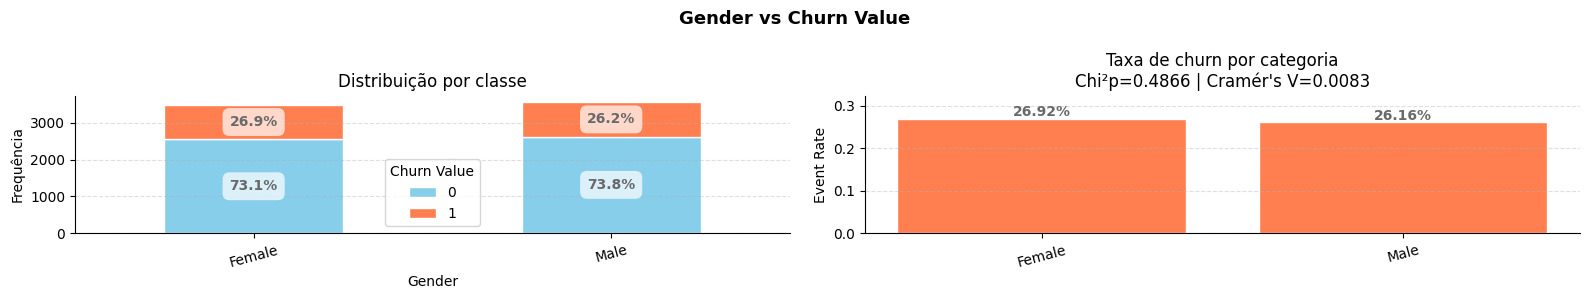

22:29:28 | INFO | Gender | n=7043 | n_cats=2 | dominante='Male' (50.5%) | minoria='Female' (49.5%) | chi2=0.4841 | p_value=0.486579 | cramer_v=0.0083
22:29:28 | INFO | Gender | categoria='Female' | n=3488 | n0=2549 | n1=939 | event_rate=0.2692
22:29:28 | INFO | Gender | categoria='Male' | n=3555 | n0=2625 | n1=930 | event_rate=0.2616
22:29:28 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_gender.png


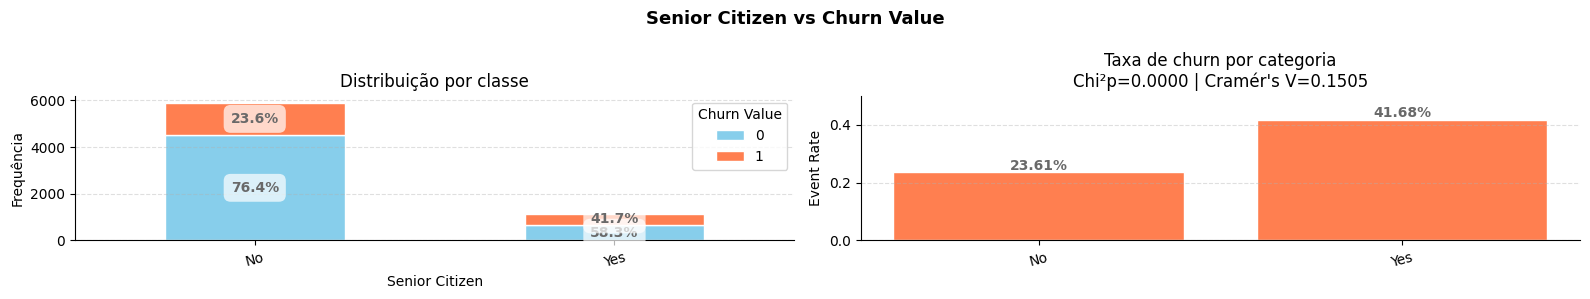

22:29:28 | INFO | Senior Citizen | n=7043 | n_cats=2 | dominante='No' (83.8%) | minoria='Yes' (16.2%) | chi2=159.4263 | p_value=0.000000 | cramer_v=0.1505
22:29:28 | INFO | Senior Citizen | categoria='No' | n=5901 | n0=4508 | n1=1393 | event_rate=0.2361
22:29:28 | INFO | Senior Citizen | categoria='Yes' | n=1142 | n0=666 | n1=476 | event_rate=0.4168
22:29:28 | WARNING | Senior Citizen | alta concentração: 'No' ocupa 83.8% — avaliar poder preditivo
22:29:28 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_senior_citizen.png


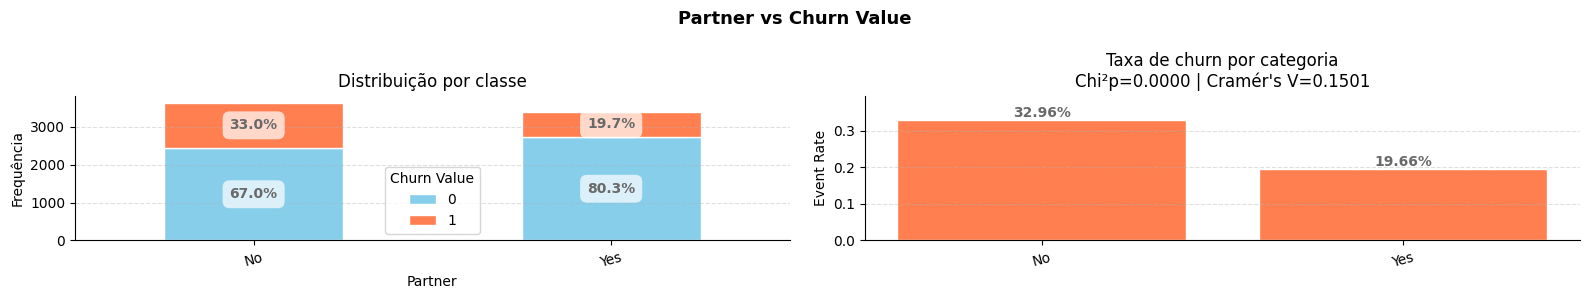

22:29:28 | INFO | Partner | n=7043 | n_cats=2 | dominante='No' (51.7%) | minoria='Yes' (48.3%) | chi2=158.7334 | p_value=0.000000 | cramer_v=0.1501
22:29:28 | INFO | Partner | categoria='No' | n=3641 | n0=2441 | n1=1200 | event_rate=0.3296
22:29:28 | INFO | Partner | categoria='Yes' | n=3402 | n0=2733 | n1=669 | event_rate=0.1966
22:29:28 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_partner.png


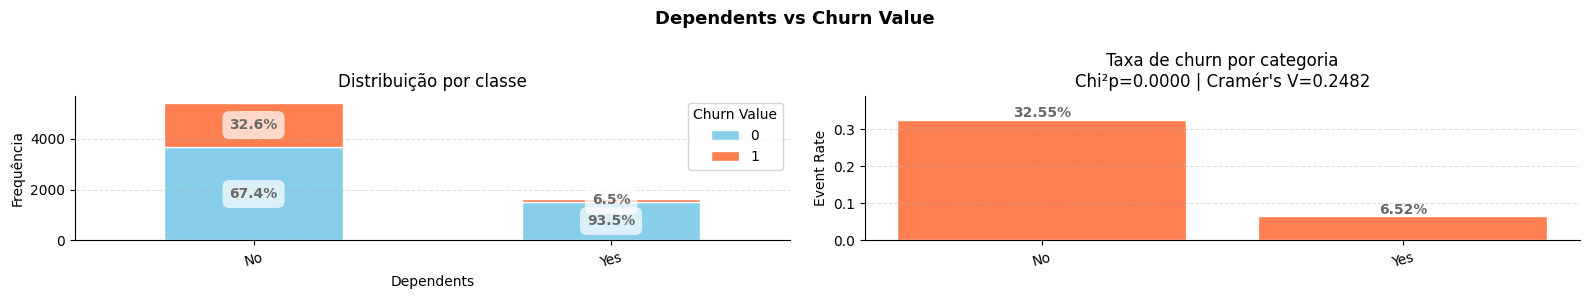

22:29:28 | INFO | Dependents | n=7043 | n_cats=2 | dominante='No' (76.9%) | minoria='Yes' (23.1%) | chi2=433.7344 | p_value=0.000000 | cramer_v=0.2482
22:29:28 | INFO | Dependents | categoria='No' | n=5416 | n0=3653 | n1=1763 | event_rate=0.3255
22:29:28 | INFO | Dependents | categoria='Yes' | n=1627 | n0=1521 | n1=106 | event_rate=0.0652
22:29:28 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_dependents.png


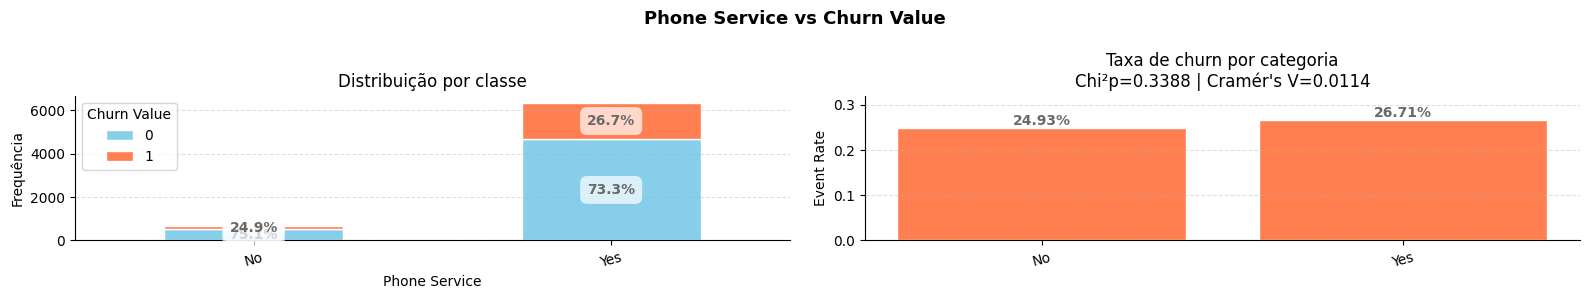

22:29:29 | INFO | Phone Service | n=7043 | n_cats=2 | dominante='Yes' (90.3%) | minoria='No' (9.7%) | chi2=0.9150 | p_value=0.338783 | cramer_v=0.0114
22:29:29 | INFO | Phone Service | categoria='No' | n=682 | n0=512 | n1=170 | event_rate=0.2493
22:29:29 | INFO | Phone Service | categoria='Yes' | n=6361 | n0=4662 | n1=1699 | event_rate=0.2671
22:29:29 | WARNING | Phone Service | alta concentração: 'Yes' ocupa 90.3% — avaliar poder preditivo
22:29:29 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_phone_service.png


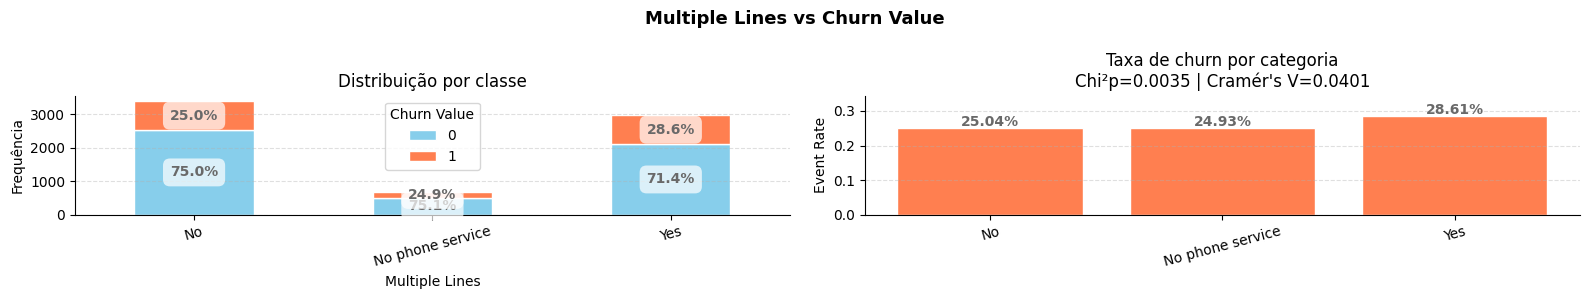

22:29:29 | INFO | Multiple Lines | n=7043 | n_cats=3 | dominante='No' (48.1%) | minoria='No phone service' (9.7%) | chi2=11.3304 | p_value=0.003464 | cramer_v=0.0401
22:29:29 | INFO | Multiple Lines | categoria='No' | n=3390 | n0=2541 | n1=849 | event_rate=0.2504
22:29:29 | INFO | Multiple Lines | categoria='No phone service' | n=682 | n0=512 | n1=170 | event_rate=0.2493
22:29:29 | INFO | Multiple Lines | categoria='Yes' | n=2971 | n0=2121 | n1=850 | event_rate=0.2861
22:29:29 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_multiple_lines.png


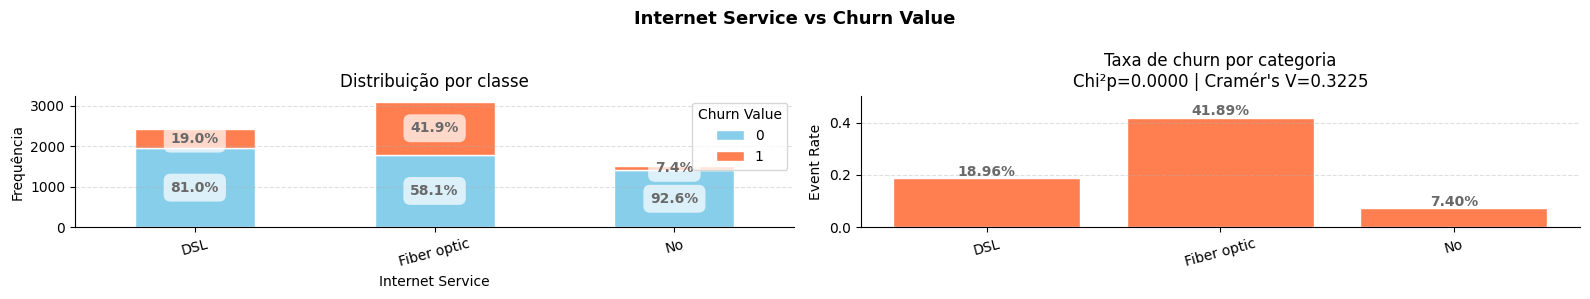

22:29:29 | INFO | Internet Service | n=7043 | n_cats=3 | dominante='Fiber optic' (44.0%) | minoria='No' (21.7%) | chi2=732.3096 | p_value=0.000000 | cramer_v=0.3225
22:29:29 | INFO | Internet Service | categoria='DSL' | n=2421 | n0=1962 | n1=459 | event_rate=0.1896
22:29:29 | INFO | Internet Service | categoria='Fiber optic' | n=3096 | n0=1799 | n1=1297 | event_rate=0.4189
22:29:29 | INFO | Internet Service | categoria='No' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
22:29:29 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_internet_service.png


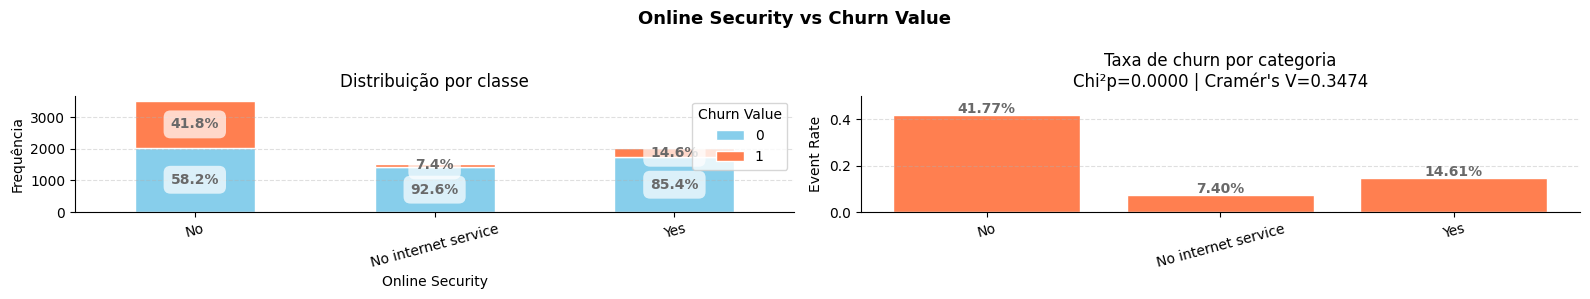

22:29:29 | INFO | Online Security | n=7043 | n_cats=3 | dominante='No' (49.7%) | minoria='No internet service' (21.7%) | chi2=849.9990 | p_value=0.000000 | cramer_v=0.3474
22:29:29 | INFO | Online Security | categoria='No' | n=3498 | n0=2037 | n1=1461 | event_rate=0.4177
22:29:29 | INFO | Online Security | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
22:29:29 | INFO | Online Security | categoria='Yes' | n=2019 | n0=1724 | n1=295 | event_rate=0.1461
22:29:29 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_online_security.png


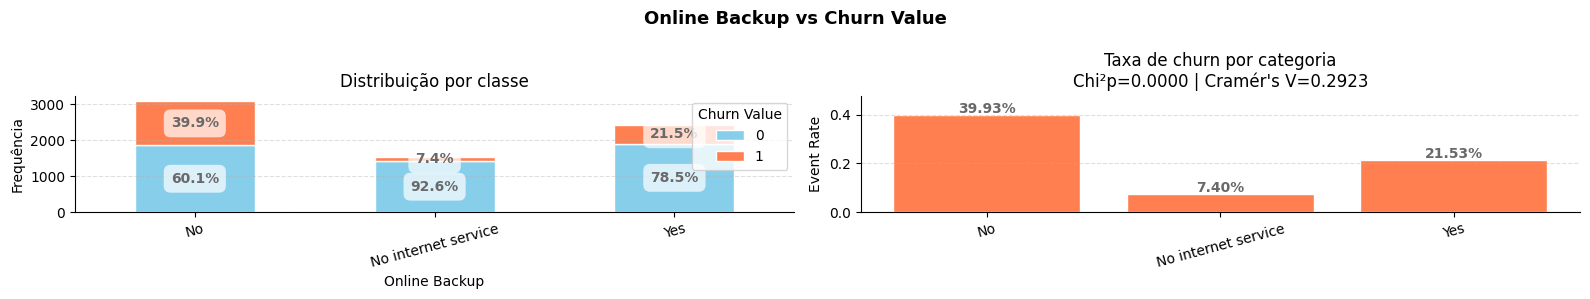

22:29:30 | INFO | Online Backup | n=7043 | n_cats=3 | dominante='No' (43.8%) | minoria='No internet service' (21.7%) | chi2=601.8128 | p_value=0.000000 | cramer_v=0.2923
22:29:30 | INFO | Online Backup | categoria='No' | n=3088 | n0=1855 | n1=1233 | event_rate=0.3993
22:29:30 | INFO | Online Backup | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
22:29:30 | INFO | Online Backup | categoria='Yes' | n=2429 | n0=1906 | n1=523 | event_rate=0.2153
22:29:30 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_online_backup.png


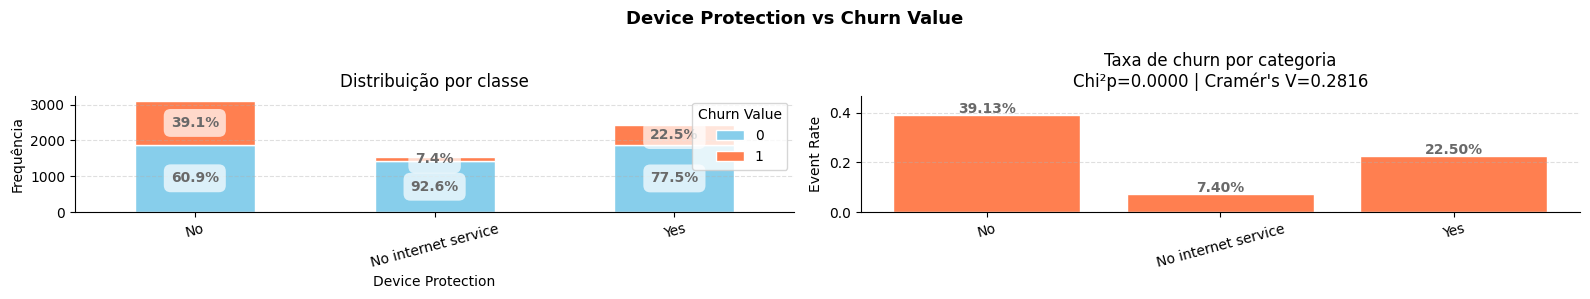

22:29:30 | INFO | Device Protection | n=7043 | n_cats=3 | dominante='No' (43.9%) | minoria='No internet service' (21.7%) | chi2=558.4194 | p_value=0.000000 | cramer_v=0.2816
22:29:30 | INFO | Device Protection | categoria='No' | n=3095 | n0=1884 | n1=1211 | event_rate=0.3913
22:29:30 | INFO | Device Protection | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
22:29:30 | INFO | Device Protection | categoria='Yes' | n=2422 | n0=1877 | n1=545 | event_rate=0.2250
22:29:30 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_device_protection.png


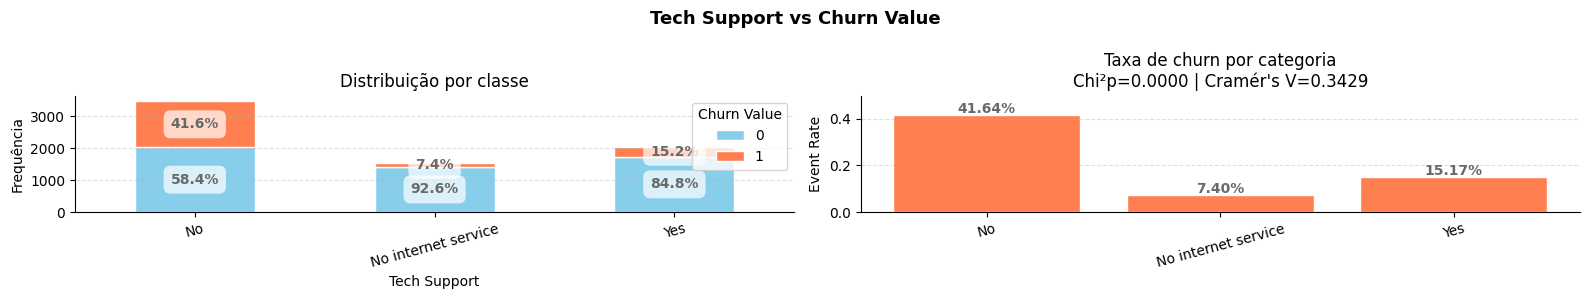

22:29:30 | INFO | Tech Support | n=7043 | n_cats=3 | dominante='No' (49.3%) | minoria='No internet service' (21.7%) | chi2=828.1971 | p_value=0.000000 | cramer_v=0.3429
22:29:30 | INFO | Tech Support | categoria='No' | n=3473 | n0=2027 | n1=1446 | event_rate=0.4164
22:29:30 | INFO | Tech Support | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
22:29:30 | INFO | Tech Support | categoria='Yes' | n=2044 | n0=1734 | n1=310 | event_rate=0.1517
22:29:30 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_tech_support.png


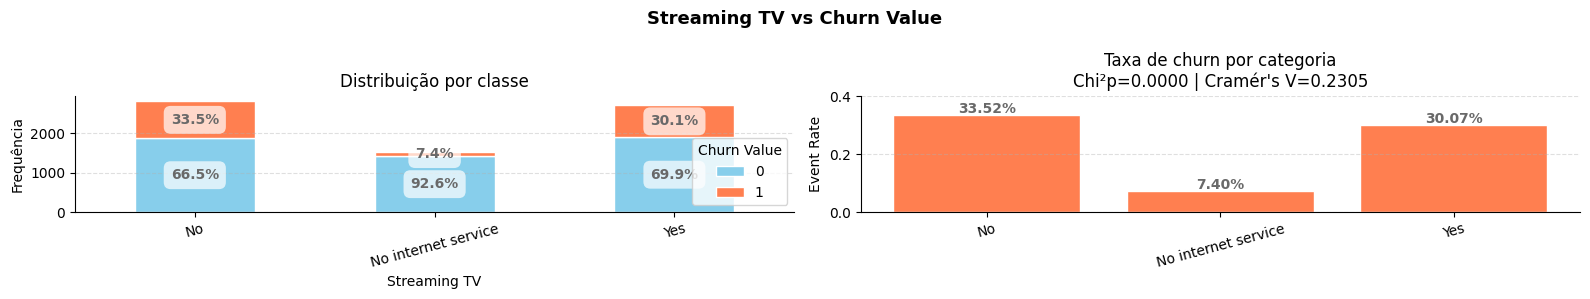

22:29:30 | INFO | Streaming TV | n=7043 | n_cats=3 | dominante='No' (39.9%) | minoria='No internet service' (21.7%) | chi2=374.2039 | p_value=0.000000 | cramer_v=0.2305
22:29:30 | INFO | Streaming TV | categoria='No' | n=2810 | n0=1868 | n1=942 | event_rate=0.3352
22:29:30 | INFO | Streaming TV | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
22:29:30 | INFO | Streaming TV | categoria='Yes' | n=2707 | n0=1893 | n1=814 | event_rate=0.3007
22:29:30 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_streaming_tv.png


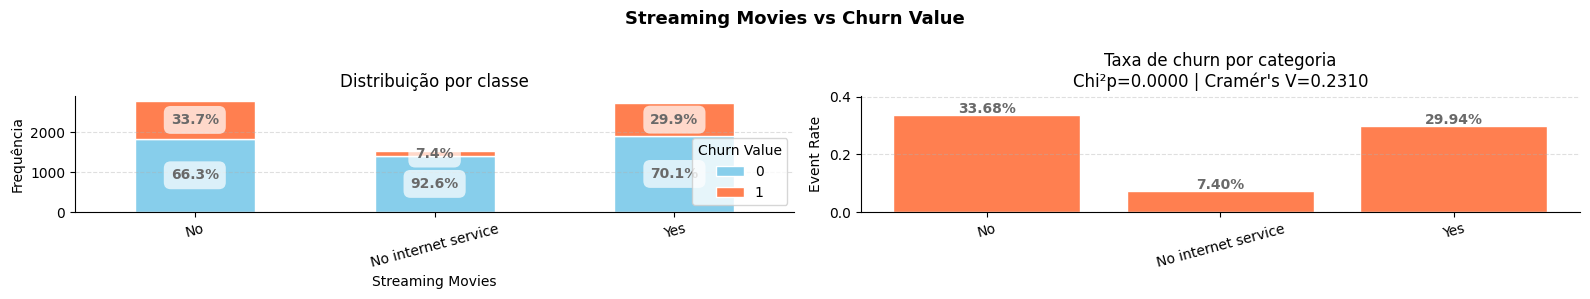

22:29:31 | INFO | Streaming Movies | n=7043 | n_cats=3 | dominante='No' (39.5%) | minoria='No internet service' (21.7%) | chi2=375.6615 | p_value=0.000000 | cramer_v=0.2310
22:29:31 | INFO | Streaming Movies | categoria='No' | n=2785 | n0=1847 | n1=938 | event_rate=0.3368
22:29:31 | INFO | Streaming Movies | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
22:29:31 | INFO | Streaming Movies | categoria='Yes' | n=2732 | n0=1914 | n1=818 | event_rate=0.2994
22:29:31 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_streaming_movies.png


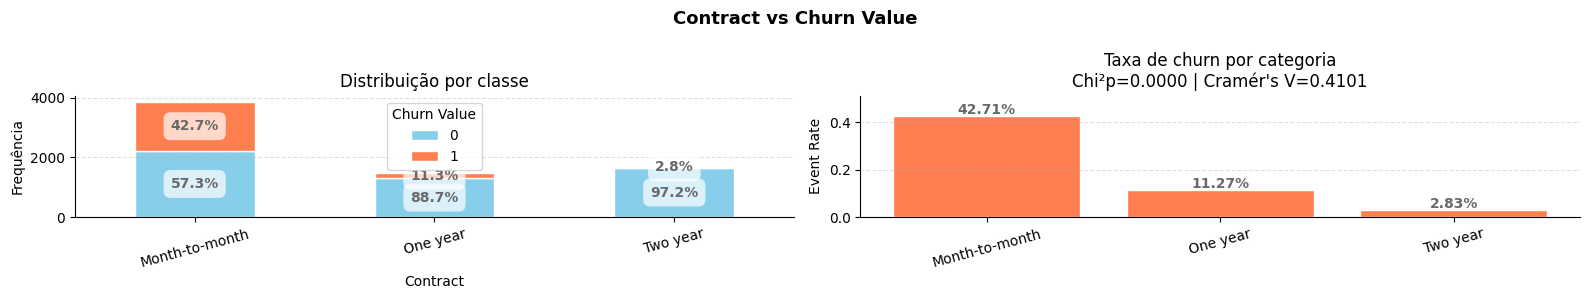

22:29:31 | INFO | Contract | n=7043 | n_cats=3 | dominante='Month-to-month' (55.0%) | minoria='One year' (20.9%) | chi2=1184.5966 | p_value=0.000000 | cramer_v=0.4101
22:29:31 | INFO | Contract | categoria='Month-to-month' | n=3875 | n0=2220 | n1=1655 | event_rate=0.4271
22:29:31 | INFO | Contract | categoria='One year' | n=1473 | n0=1307 | n1=166 | event_rate=0.1127
22:29:31 | INFO | Contract | categoria='Two year' | n=1695 | n0=1647 | n1=48 | event_rate=0.0283
22:29:31 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_contract.png


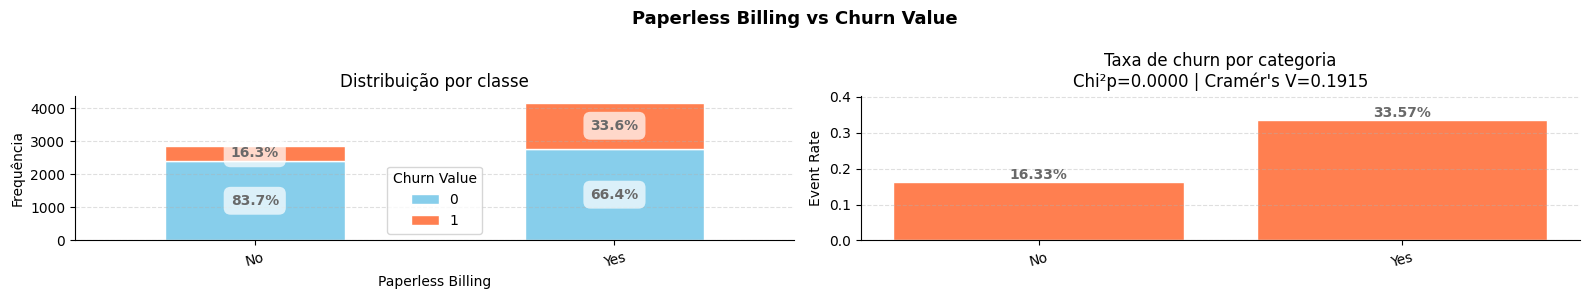

22:29:31 | INFO | Paperless Billing | n=7043 | n_cats=2 | dominante='Yes' (59.2%) | minoria='No' (40.8%) | chi2=258.2776 | p_value=0.000000 | cramer_v=0.1915
22:29:31 | INFO | Paperless Billing | categoria='No' | n=2872 | n0=2403 | n1=469 | event_rate=0.1633
22:29:31 | INFO | Paperless Billing | categoria='Yes' | n=4171 | n0=2771 | n1=1400 | event_rate=0.3357
22:29:31 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_paperless_billing.png


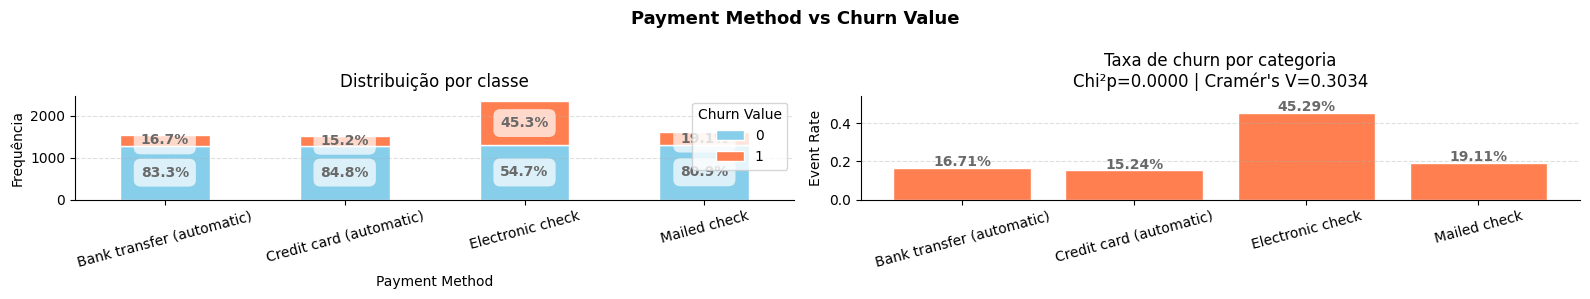

22:29:32 | INFO | Payment Method | n=7043 | n_cats=4 | dominante='Electronic check' (33.6%) | minoria='Credit card (automatic)' (21.6%) | chi2=648.1423 | p_value=0.000000 | cramer_v=0.3034
22:29:32 | INFO | Payment Method | categoria='Bank transfer (automatic)' | n=1544 | n0=1286 | n1=258 | event_rate=0.1671
22:29:32 | INFO | Payment Method | categoria='Credit card (automatic)' | n=1522 | n0=1290 | n1=232 | event_rate=0.1524
22:29:32 | INFO | Payment Method | categoria='Electronic check' | n=2365 | n0=1294 | n1=1071 | event_rate=0.4529
22:29:32 | INFO | Payment Method | categoria='Mailed check' | n=1612 | n0=1304 | n1=308 | event_rate=0.1911
22:29:32 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_payment_method.png
22:29:32 | INFO | Análise bivariada finalizada para 16 variáveis categóricas.


In [38]:
logger.info("Análise bivariada iniciada para %d variáveis categóricas.", len(COLS_CAT))

for col in COLS_CAT:
    series = df[[col, TARGET]].dropna()

    freq_abs = series[col].value_counts()
    freq_rel = series[col].value_counts(normalize=True).mul(100).round(1)

    n_cats = series[col].nunique()
    n_total = len(series)
    dominante = freq_abs.index[0]
    minoria = freq_abs.index[-1]

    crosstab = pd.crosstab(series[col], series[TARGET])
    if 0 not in crosstab.columns:
        crosstab[0] = 0
    if 1 not in crosstab.columns:
        crosstab[1] = 0
    crosstab = crosstab[[0, 1]]

    churn_rate = (crosstab[1] / (crosstab[0] + crosstab[1])).fillna(0)
    chi2, p_value, _, _ = chi2_contingency(crosstab)

    n = crosstab.sum().sum()
    phi2 = chi2 / n
    r, k = crosstab.shape
    cramer_v = np.sqrt(phi2 / min(k - 1, r - 1)) if min(k - 1, r - 1) > 0 else 0

    cats_raras = freq_rel[freq_rel < 1.0]
    alta_concentracao = freq_rel.iloc[0] > 80.0

    altura = max(3, n_cats * 0.6)
    fig, axes = plt.subplots(1, 2, figsize=(16, altura))
    fig.suptitle(f"{col} vs {TARGET}", fontsize=13, fontweight="bold")

    crosstab.plot(
        kind="bar",
        stacked=True,
        ax=axes[0],
        color=[CORES["primaria"], CORES["destaque"]],
        edgecolor="white",
    )
    axes[0].set_title("Distribuição por classe")
    axes[0].set_ylabel("Frequência")
    axes[0].tick_params(axis="x", rotation=15)
    axes[0].yaxis.grid(True, linestyle="--", alpha=0.4)
    axes[0].spines[["top", "right"]].set_visible(False)

    for i, cat in enumerate(crosstab.index):
        n0 = crosstab.loc[cat, 0]
        n1 = crosstab.loc[cat, 1]
        total = n0 + n1
        pct_0 = n0 / total if total > 0 else 0
        pct_1 = n1 / total if total > 0 else 0
        y0, y1 = n0 / 2, n0 + (n1 / 2)
        for y, pct in [(y0, pct_0), (y1, pct_1)]:
            axes[0].text(
                i,
                y,
                f"{pct:.1%}",
                ha="center",
                va="center",
                fontsize=10,
                color=CORES["neutro"],
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    boxstyle="round,pad=0.5",
                    alpha=0.7,
                ),
            )

    axes[1].bar(
        churn_rate.index, churn_rate.values, color=CORES["destaque"], edgecolor="white"
    )
    axes[1].set_title(
        f"Taxa de churn por categoria\nChi²p={p_value:.4f} | Cramér's V={cramer_v:.4f}"
    )
    axes[1].set_ylabel("Event Rate")
    axes[1].set_ylim(0, churn_rate.max() * 1.2)
    axes[1].tick_params(axis="x", rotation=15)
    axes[1].yaxis.grid(True, linestyle="--", alpha=0.4)
    axes[1].spines[["top", "right"]].set_visible(False)

    for i, v in enumerate(churn_rate.values):
        axes[1].text(
            i,
            v + churn_rate.max() * 0.02,
            f"{v:.2%}",
            ha="center",
            fontsize=10,
            color=CORES["neutro"],
            fontweight="bold",
        )

    plt.tight_layout()
    output_path = (
        REPORTS_FIGURES_MULTIVARIADA
        / f"bivariate_cat_{col.lower().replace(' ', '_')}.png"
    )
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

    logger.info(
        "%s | n=%d | n_cats=%d | dominante='%s' (%.1f%%) | minoria='%s' (%.1f%%) | "
        "chi2=%.4f | p_value=%.6f | cramer_v=%.4f",
        col,
        n_total,
        n_cats,
        dominante,
        freq_rel.iloc[0],
        minoria,
        freq_rel.iloc[-1],
        chi2,
        p_value,
        cramer_v,
    )

    for cat in crosstab.index:
        n0 = crosstab.loc[cat, 0]
        n1 = crosstab.loc[cat, 1]
        total = n0 + n1
        rate = churn_rate.loc[cat]
        logger.info(
            "%s | categoria='%s' | n=%d | n0=%d | n1=%d | event_rate=%.4f",
            col,
            cat,
            total,
            n0,
            n1,
            rate,
        )

    for cat, pct in cats_raras.items():
        logger.warning(
            "%s | categoria rara: '%s' = %.1f%% (%d registros)",
            col,
            cat,
            pct,
            freq_abs.loc[cat],
        )
    if alta_concentracao:
        logger.warning(
            "%s | alta concentração: '%s' ocupa %.1f%% — avaliar poder preditivo",
            col,
            dominante,
            freq_rel.iloc[0],
        )
    logger.info("Artefato salvo: %s", output_path)

logger.info(
    "Análise bivariada finalizada para %d variáveis categóricas.", len(COLS_CAT)
)

---
## 8. Multicolinearidade — Correlação de Pearson + VIF

### Por que verificar multicolinearidade?

O impacto da multicolinearidade **depende do tipo de modelo**. Em modelos lineares,
duas features altamente correlacionadas inflam os coeficientes e tornam as estimativas
instáveis — o modelo não consegue separar o efeito individual de cada variável. Em
MLPs, o backpropagation redistribui os gradientes entre os pesos naturalmente: se duas
features são redundantes, a rede aprende a atenuar uma delas sem instabilidade
estrutural. Por isso, a decisão de remover uma feature por multicolinearidade **não
deve ser aplicada de forma global** — ela é modelo-dependente.

### Métricas utilizadas

| Métrica | Interpretação | Limiar de atenção |
|---------|--------------|-------------------|
| **Correlação de Pearson** | Associação linear entre duas features | \|r\| ≥ 0.70 |
| **VIF (Variance Inflation Factor)** | Quanto de uma feature é explicado pelas demais | VIF > 5 (atenção) / > 10 (crítico) |

> **Resultado esperado:** `Tenure Months` e `Total Charges` apresentarão correlação
> ≈ 0.83, pois `Total Charges ≈ Tenure × Monthly Charges`. O VIF de `Total Charges`
> ficará próximo de 8 — confirmando redundância estrutural **para modelos lineares**.
>
> Para a MLP, a análise bivariada (Seção 6) registrou Cohen's d = -0,48 (efeito
> médio) para `Total Charges`, indicando sinal preditivo independente suficiente para
> justificar sua permanência como feature de entrada da rede neural. A decisão de
> remoção será, portanto, **delegada ao pipeline de cada modelo**.

---

22:29:32 | INFO | Iniciando análise de correlação e multicolinearidade.


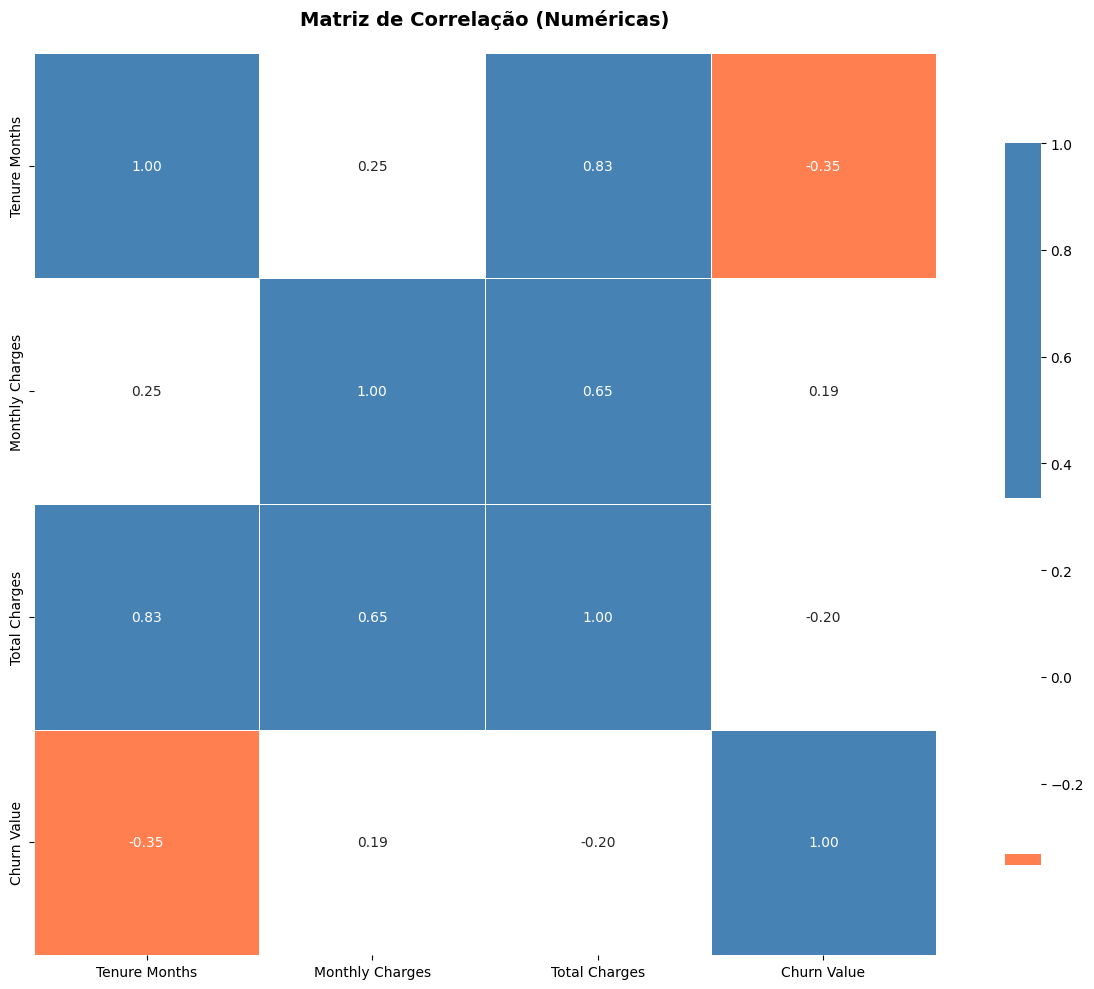

22:29:32 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\correlacao\correlation_matrix_numeric.png
22:29:32 | INFO | === CORRELAÇÕES COM TARGET ===
22:29:32 | INFO | Monthly Charges | corr_target=0.1934
22:29:32 | INFO | Total Charges | corr_target=-0.1995
22:29:32 | INFO | Tenure Months | corr_target=-0.3522
22:29:32 | INFO | === ANÁLISE DE MULTICOLINEARIDADE (CORR) ===
22:29:32 | WARNING | Foram encontrados 1 pares com correlação >= 0.70
22:29:32 | WARNING | HIGH_CORR | Tenure Months vs Total Charges | corr=0.8259
22:29:32 | INFO | === ANÁLISE DE VIF (MULTICOLINEARIDADE AVANÇADA) ===
22:29:32 | INFO | Feature: Total Charges        | VIF: 8.0792
22:29:32 | INFO | Feature: Tenure Months        | VIF: 6.3324
22:29:32 | INFO | Feature: Monthly Charges      | VIF: 3.3611
22:29:32 | INFO | Análise de correlação e multicolinearidade finalizada.


,feature,vif
2,Total Charges,8.0792
0,Tenure Months,6.3324
1,Monthly Charges,3.3611


In [39]:
logger.info("Iniciando análise de correlação e multicolinearidade.")

df_num = df.select_dtypes(include=[np.number]).copy()

corr_matrix = df_num.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=sns.color_palette(
        [CORES["destaque"], "white", CORES["secundaria"]], as_cmap=True
    ),
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Matriz de Correlação (Numéricas)", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
output_path = REPORT_FIGURES_CORRELACAO / "correlation_matrix_numeric.png"
plt.savefig(output_path, dpi=120, bbox_inches="tight")
plt.show()
plt.close()
logger.info("Artefato salvo: %s", output_path)

# ── Correlação com TARGET ──────────────────────────────────────────────────────
if TARGET in corr_matrix.columns:
    target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
    logger.info("=== CORRELAÇÕES COM TARGET ===")
    for feature, value in target_corr.items():
        logger.info("%s | corr_target=%.4f", feature, value)

# ── Pares com alta correlação entre features ──────────────────────────────────
logger.info("=== ANÁLISE DE MULTICOLINEARIDADE (CORR) ===")
threshold = 0.7
high_corr_pairs = []
cols = corr_matrix.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        f1, f2 = cols[i], cols[j]
        if f1 == TARGET or f2 == TARGET:
            continue
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) >= threshold:
            high_corr_pairs.append(
                {"feature_1": f1, "feature_2": f2, "correlation": round(corr_val, 4)}
            )

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
        by="correlation", ascending=False
    )
    logger.warning(
        "Foram encontrados %d pares com correlação >= %.2f",
        len(high_corr_df),
        threshold,
    )
    for _, row in high_corr_df.iterrows():
        logger.warning(
            "HIGH_CORR | %s vs %s | corr=%.4f",
            row["feature_1"],
            row["feature_2"],
            row["correlation"],
        )
else:
    logger.info("Nenhuma correlação forte detectada entre features.")

# ── VIF ───────────────────────────────────────────────────────────────────────
logger.info("=== ANÁLISE DE VIF (MULTICOLINEARIDADE AVANÇADA) ===")
features_vif = df_num.drop(columns=[TARGET], errors="ignore").dropna()
vif_data = []
for i in range(features_vif.shape[1]):
    vif = variance_inflation_factor(features_vif.values, i)
    vif_data.append({"feature": features_vif.columns[i], "vif": round(vif, 4)})

vif_df = pd.DataFrame(vif_data).sort_values(by="vif", ascending=False)
for _, row in vif_df.iterrows():
    logger.info("Feature: %-20s | VIF: %.4f", row["feature"], row["vif"])

logger.info("Análise de correlação e multicolinearidade finalizada.")
display(vif_df)

---
## 9. Feature Selection — Decisão Final e Exportação

Com base nas evidências levantadas nas Seções 4 a 8, são aplicadas duas categorias
de decisão com escopos distintos:

### 9.1 Remoção global — sem sinal preditivo em nenhum modelo

As features abaixo são descartadas do dataset antes de qualquer treinamento, pois não
apresentam associação estatisticamente significativa com o target em nenhuma análise:

| Coluna | Motivo do Descarte | Evidência |
|--------|--------------------|-----------|
| `Gender` | Sem associação com churn (Chi² p=0.487, Cramér's V=0.008). Distribuição praticamente idêntica entre as classes. | Seção 7 |
| `Phone Service` | Sem associação com churn (Chi² p=0.339, Cramér's V=0.011). Alta concentração (90.3% "Yes") sem sinal discriminatório entre grupos. | Seções 5 e 7 |

### 9.2 Remoção modelo-dependente — multicolinearidade

`Total Charges` possui sinal preditivo real (Cohen's d = -0.48, efeito médio) mas
apresenta redundância estrutural com `Tenure Months` (corr=0.83, VIF≈8):

| Modelo | Decisão para `Total Charges` | Justificativa |
|--------|------------------------------|---------------|
| **Regressão Logística** (baseline) | ❌ **Remover** | VIF≈8 infla coeficientes e instabiliza estimativas em modelos lineares. |
| **MLP PyTorch** | ✅ **Manter** | Backpropagation redistribui gradientes naturalmente; Cohen's d=-0.48 confirma sinal preditivo independente. |

> **Decisão de design:** o `telco_droped.parquet` exportado nesta etapa **mantém
> `Total Charges`**, preservando o sinal para a MLP. A remoção desta coluna será
> aplicada exclusivamente dentro do pipeline da Regressão Logística, na Etapa de
> Pré-Processamento — tornando a decisão auditável por modelo no MLflow.

**Features exportadas:** 18 colunas (3 numéricas + 14 categóricas + 1 target).

> **Escopo desta exportação:** apenas o descarte de colunas sem sinal preditivo
> (`Gender` e `Phone Service`). Transformações numéricas (PowerTransformer,
> StandardScaler), encoding de categóricas (OrdinalEncoder, OneHotEncoder),
> remoção modelo-dependente de features e engenharia de atributos serão
> responsabilidade exclusiva do **pipeline de pré-processamento**
> (Etapa 1 — notebook `1.01-preprocessing`).


In [40]:
df.head(5)

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [41]:
# Remoção global — features sem sinal preditivo em nenhum modelo (Seção 9.1)
# Total Charges é mantida aqui — sua remoção é modelo-dependente e será
# aplicada exclusivamente no pipeline da Regressão Logística (Etapa de Pré-Processamento)
COLS_TO_DROP = ["Gender", "Phone Service"]

df_dropped = df.drop(columns=COLS_TO_DROP).copy()

logger.info(
    "Feature selection aplicada | colunas removidas: %s | shape antes: %s | shape depois: %s",
    COLS_TO_DROP,
    df.shape,
    df_dropped.shape,
)

# Validação: confirmar que as colunas foram removidas e o restante está íntegro
assert all(col not in df_dropped.columns for col in COLS_TO_DROP), (
    "Erro: alguma coluna alvo ainda está presente no dataset."
)
assert TARGET in df_dropped.columns, "Erro: target foi removido acidentalmente."
assert "Total Charges" in df_dropped.columns, (
    "Erro: Total Charges foi removida — deve ser preservada para a MLP."
)
assert df_dropped.shape[0] == df.shape[0], "Erro: número de linhas alterado."
assert df_dropped.shape[1] == 18, (
    f"Erro: shape esperado (7043, 18), obtido {df_dropped.shape}."
)

logger.info("Validação do shape pós-drop concluída com sucesso.")

# Persistência — entrada da Etapa de Pré-Processamento
output_path = DATA_INTERIM / "telco_droped.parquet"
df_dropped.to_parquet(output_path, index=False)

logger.info(
    "Dataset salvo: %s — shape final: %s | colunas: %s",
    output_path,
    df_dropped.shape,
    list(df_dropped.columns),
)

df_dropped.head(5)

22:29:32 | INFO | Feature selection aplicada | colunas removidas: ['Gender', 'Phone Service'] | shape antes: (7043, 20) | shape depois: (7043, 18)
22:29:32 | INFO | Validação do shape pós-drop concluída com sucesso.
22:29:32 | INFO | Dataset salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\data\interim\telco_droped.parquet — shape final: (7043, 18) | colunas: ['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']


,Senior Citizen,Partner,Dependents,Tenure Months,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,No,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,No,No,Yes,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,No,No,Yes,8,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,No,Yes,Yes,28,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,No,No,Yes,49,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [42]:
# Sumário final das features exportadas — telco_droped.parquet
_df = df_dropped.drop(columns=[TARGET])

# Classificação de tipo baseada nas listas do config
_tipo = {col: "numérica" for col in COLS_NUM if col in _df.columns}
_tipo.update({col: "categórica" for col in COLS_CAT if col in _df.columns})

# Escopo por modelo — Total Charges é mantida apenas para a MLP
# A Regressão Logística removerá essa coluna em seu próprio pipeline (VIF≈8)
_scope = {col: "Todos os modelos" for col in _df.columns}
_scope["Total Charges"] = "MLP only (multicolinear para modelos lineares)"

summary = pd.DataFrame(
    {
        "feature": _df.columns,
        "tipo": [_tipo.get(col, "—") for col in _df.columns],
        "dtype": _df.dtypes.values,
        "n_unique": _df.nunique().values,
        "nulls": _df.isnull().sum().values,
        "pct_nulls": (_df.isnull().sum() / len(_df) * 100).round(2).values,
        "model_scope": [_scope[col] for col in _df.columns],
    }
)

display(summary)

logger.info(
    "EDA finalizada | colunas exportadas: %d (%d features + 1 target) | "
    "numéricas: %d | categóricas: %d | "
    "nulls totais: %d | dataset: telco_droped.parquet",
    df_dropped.shape[1],
    len(_df.columns),
    sum(v == "numérica" for v in _tipo.values()),
    sum(v == "categórica" for v in _tipo.values()),
    _df.isnull().sum().sum(),
)

,feature,tipo,dtype,n_unique,nulls,pct_nulls,model_scope
0,Senior Citizen,categórica,object,2,0,0.00,Todos os modelos
1,Partner,categórica,object,2,0,0.00,Todos os modelos
2,Dependents,categórica,object,2,0,0.00,Todos os modelos
3,Tenure Months,numérica,int64,73,0,0.00,Todos os modelos
4,Multiple Lines,categórica,object,3,0,0.00,Todos os modelos
5,Internet Service,categórica,object,3,0,0.00,Todos os modelos
6,Online Security,categórica,object,3,0,0.00,Todos os modelos
7,Online Backup,categórica,object,3,0,0.00,Todos os modelos
8,Device Protection,categórica,object,3,0,0.00,Todos os modelos
9,Tech Support,categórica,object,3,0,0.00,Todos os modelos


22:29:32 | INFO | EDA finalizada | colunas exportadas: 18 (17 features + 1 target) | numéricas: 3 | categóricas: 14 | nulls totais: 11 | dataset: telco_droped.parquet
